# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [2]:
import pandas as pd

data = pd.concat([X, y], axis=1)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


# Generating synthetic data

In [3]:
# Import SDV libraries
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = len(data)

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data= data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())

c:\Users\Gopi.Battineni\AppData\Local\anaconda3\envs\UGE\Lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Gopi.Battineni\AppData\Local\anaconda3\envs\UGE\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(



Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 604.42it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 250.11it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 237.11it/s]|
Column Shapes Score: 86.67%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 198.01it/s]|
Column Pair Trends Score: 87.51%

Overall Score (Average): 87.09%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 1390.34it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 788.70it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 518.86it/s]|
Column Shapes Score: 88.39%

(2/2) E

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.951731
1,TVAE,1.0,0.947430
2,CTGAN,1.0,0.870891
3,CopulaGAN,1.0,0.869136



Best model by quality score: GaussianCopula


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.87,0.549,0.16,4.79,0.068,21.7,107.4,0.999457,3.23,0.60,9.636078,6
1,8.30,0.391,0.37,3.12,0.054,21.0,29.7,0.996112,3.28,0.46,10.934984,6
2,9.27,0.402,0.37,1.40,0.157,4.2,18.0,0.997598,3.30,0.68,10.587821,6
3,5.66,0.160,0.14,3.32,0.040,21.6,125.4,0.992843,3.33,0.33,9.816687,6
4,6.81,0.257,0.24,3.45,0.048,51.1,113.9,0.995028,3.19,0.34,10.094906,6


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 516.65it/s]|
Column Shapes Score: 86.67%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 435.08it/s]|
Column Pair Trends Score: 87.51%

Overall Score (Average): 87.09%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 581.23it/s]|
Column Shapes Score: 88.39%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 434.89it/s]|
Column Pair Trends Score: 85.44%

Overall Score (Average): 86.91%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 502.41it/s]|
Column Shapes Score: 91.86%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 382.87it/s]|
Column Pair Trends Score: 97.63%

Overall Score (Average): 94.74%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 345.36it/s]|
Column Shapes Score: 91.86%

(2/2) Evaluating Column Pair T

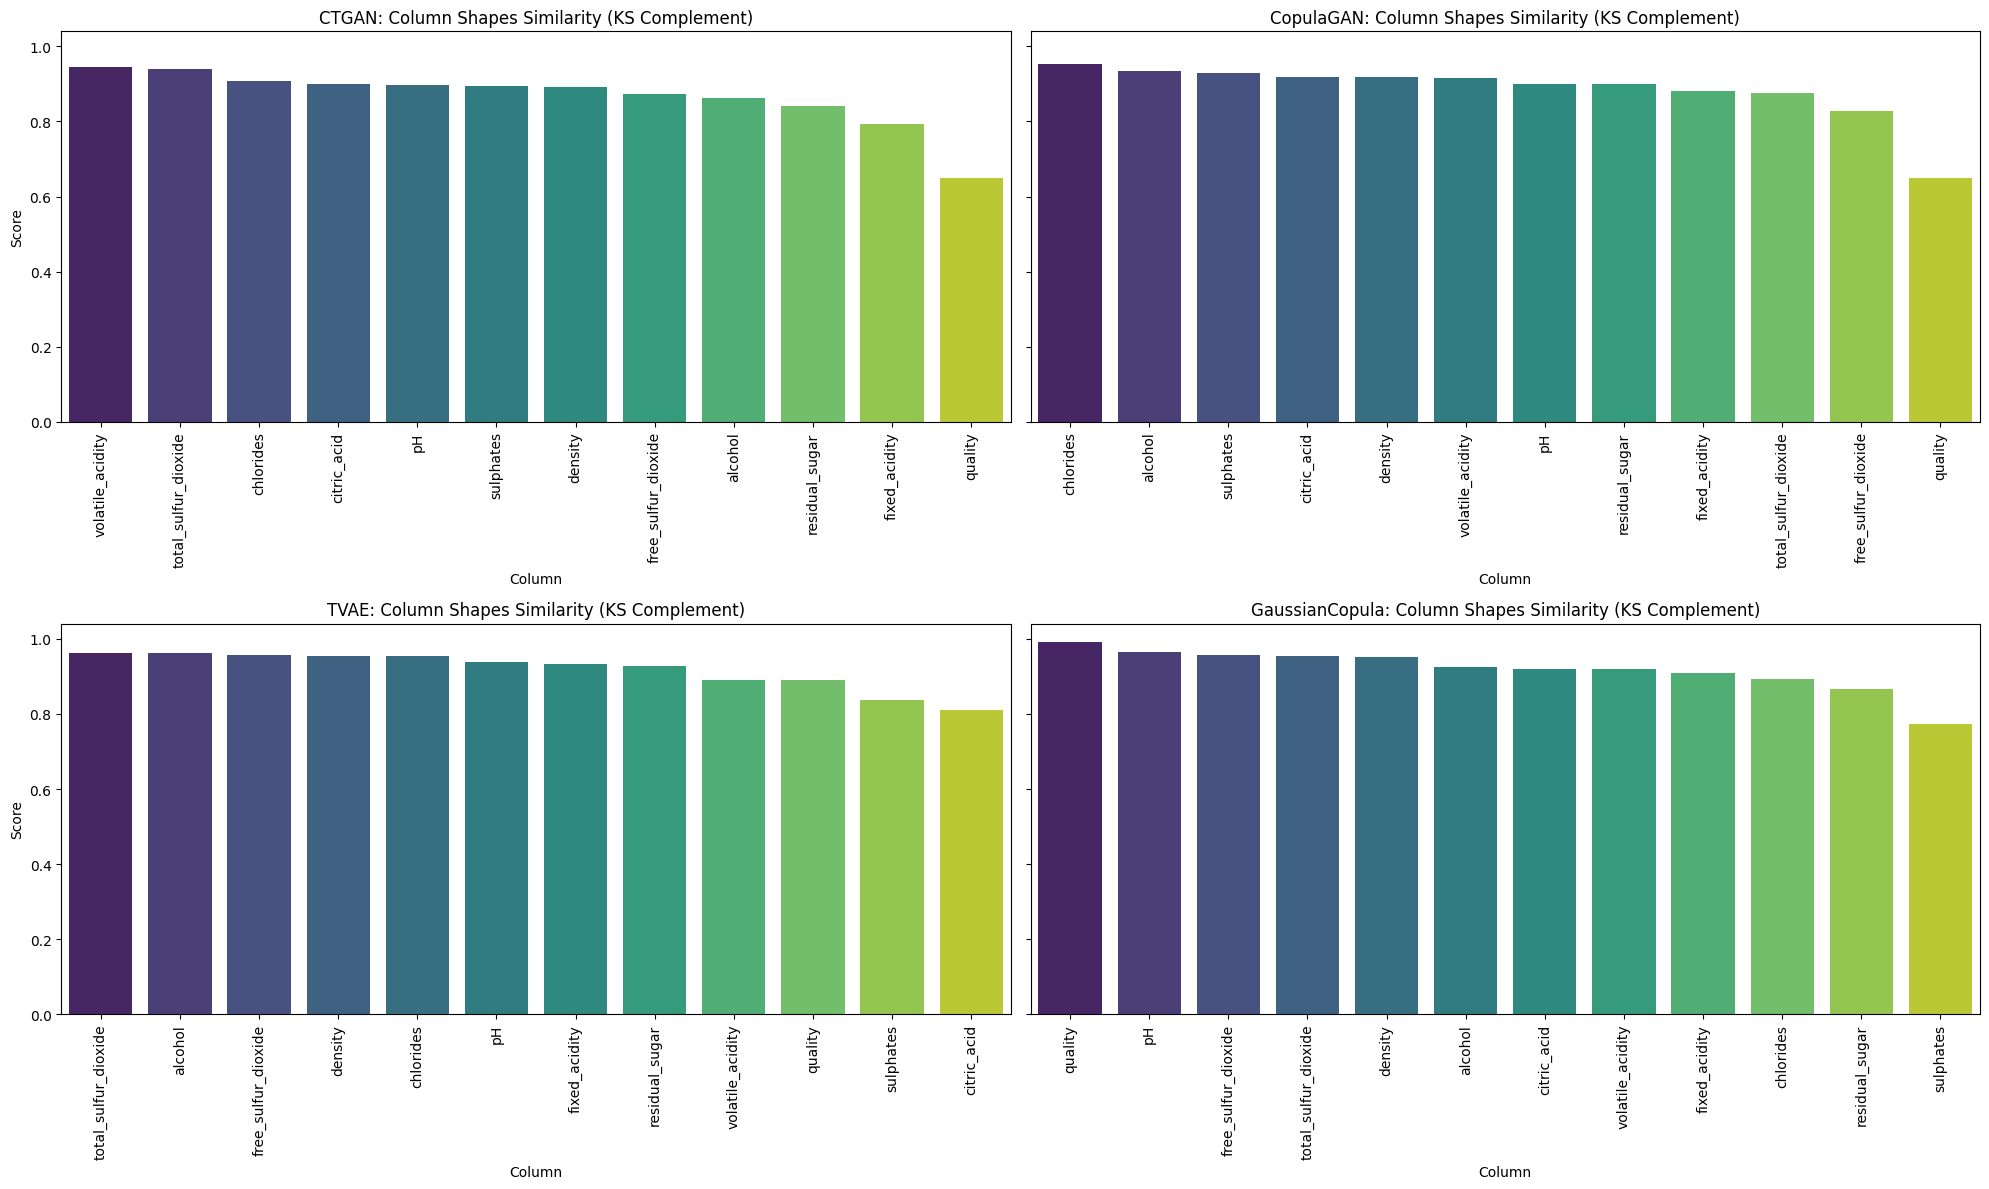

,Column,Metric,Score,Model
0,volatile_acidity,KSComplement,0.945052,CTGAN
1,total_sulfur_dioxide,KSComplement,0.941204,CTGAN
2,chlorides,KSComplement,0.907804,CTGAN
3,citric_acid,KSComplement,0.900416,CTGAN
4,pH,KSComplement,0.898107,CTGAN
5,sulphates,KSComplement,0.895798,CTGAN
6,density,KSComplement,0.891642,CTGAN
7,free_sulfur_dioxide,KSComplement,0.874404,CTGAN
8,alcohol,KSComplement,0.861628,CTGAN
9,residual_sugar,KSComplement,0.841927,CTGAN


In [4]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "quality"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


### 1.2. Jensen–Shannon divergence

In [5]:
import numpy as np
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


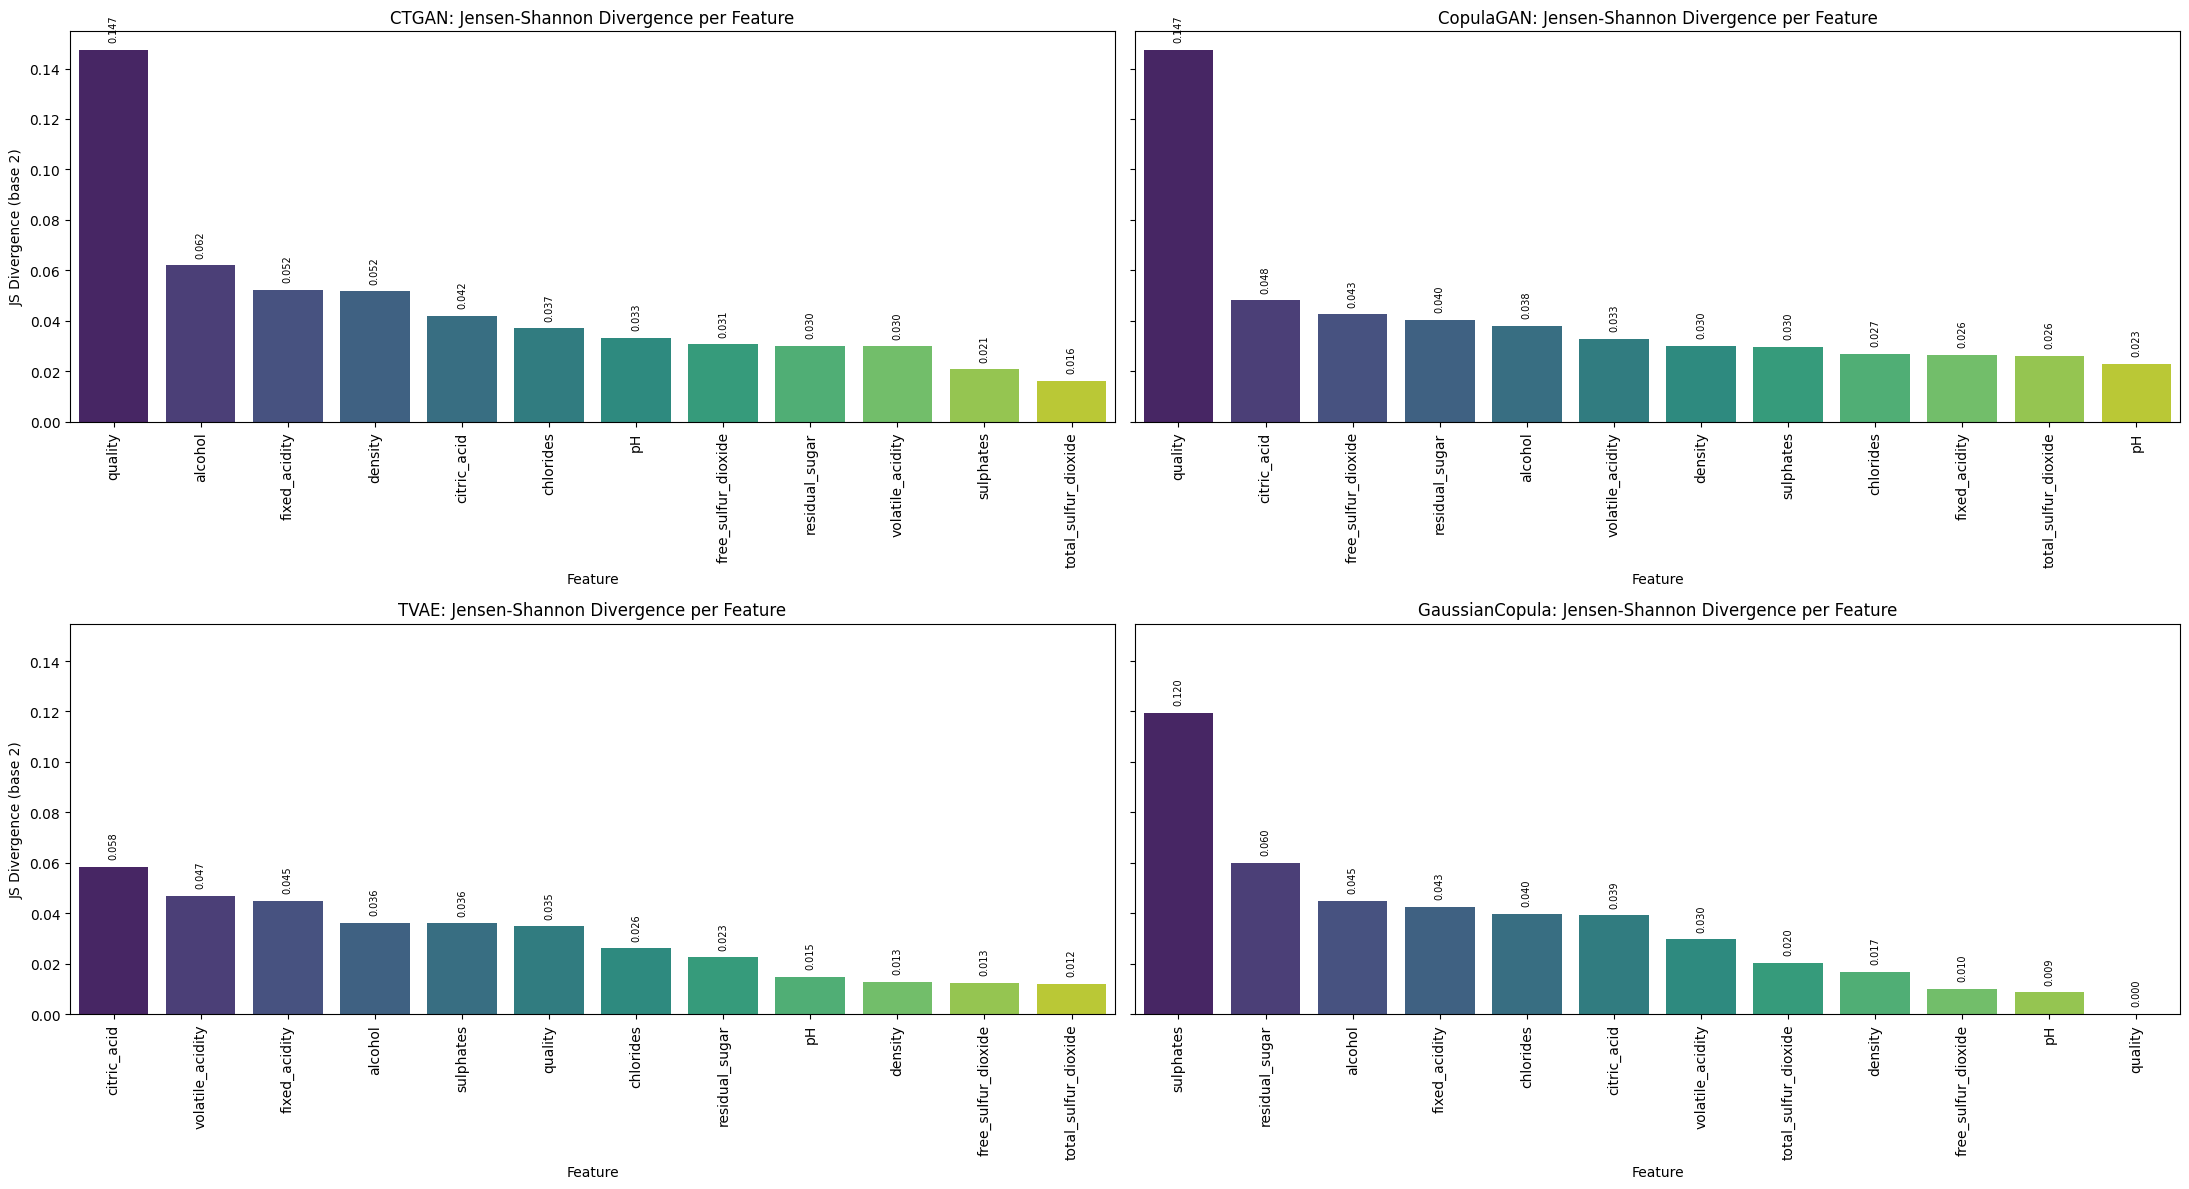

,Feature,JS_Divergence,Model
0,quality,0.147344,CTGAN
1,alcohol,0.062065,CTGAN
2,fixed_acidity,0.052168,CTGAN
3,density,0.051602,CTGAN
4,citric_acid,0.041964,CTGAN
5,chlorides,0.036972,CTGAN
6,pH,0.033312,CTGAN
7,free_sulfur_dioxide,0.030634,CTGAN
8,residual_sugar,0.030143,CTGAN
9,volatile_acidity,0.029782,CTGAN


In [6]:
import matplotlib.pyplot as plt, numpy as np
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

# Compute JS divergence for each model
for model_name in model_order:
    js_df = compute_js_divergence(
        data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    # Add value labels
    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
fixed_acidity: 0.0315
volatile_acidity: 0.0089
citric_acid: 0.0101
residual_sugar: 0.0191
chlorides: 0.0049
free_sulfur_dioxide: 0.0126
total_sulfur_dioxide: 0.0135
density: 0.0149
pH: 0.0209
sulphates: 0.0120
alcohol: 0.0504
quality: 0.1175

CopulaGAN - Wasserstein Distance:
fixed_acidity: 0.0179
volatile_acidity: 0.0144
citric_acid: 0.0134
residual_sugar: 0.0131
chlorides: 0.0050
free_sulfur_dioxide: 0.0188
total_sulfur_dioxide: 0.0350
density: 0.0092
pH: 0.0254
sulphates: 0.0139
alcohol: 0.0182
quality: 0.1175

TVAE - Wasserstein Distance:
fixed_acidity: 0.0121
volatile_acidity: 0.0161
citric_acid: 0.0203
residual_sugar: 0.0053
chlorides: 0.0073
free_sulfur_dioxide: 0.0059
total_sulfur_dioxide: 0.0092
density: 0.0049
pH: 0.0171
sulphates: 0.0236
alcohol: 0.0105
quality: 0.0257

GaussianCopula - Wasserstein Distance:
fixed_acidity: 0.0164
volatile_acidity: 0.0113
citric_acid: 0.0106
residual_sugar: 0.0100
chlorides: 0.0085
free_sulfur_dioxide: 0.0042
to

,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.011826,0.009801,0.040755
1,TVAE,0.013171,0.011299,0.025704
2,CopulaGAN,0.025152,0.016145,0.117541
3,CTGAN,0.026365,0.014213,0.117516


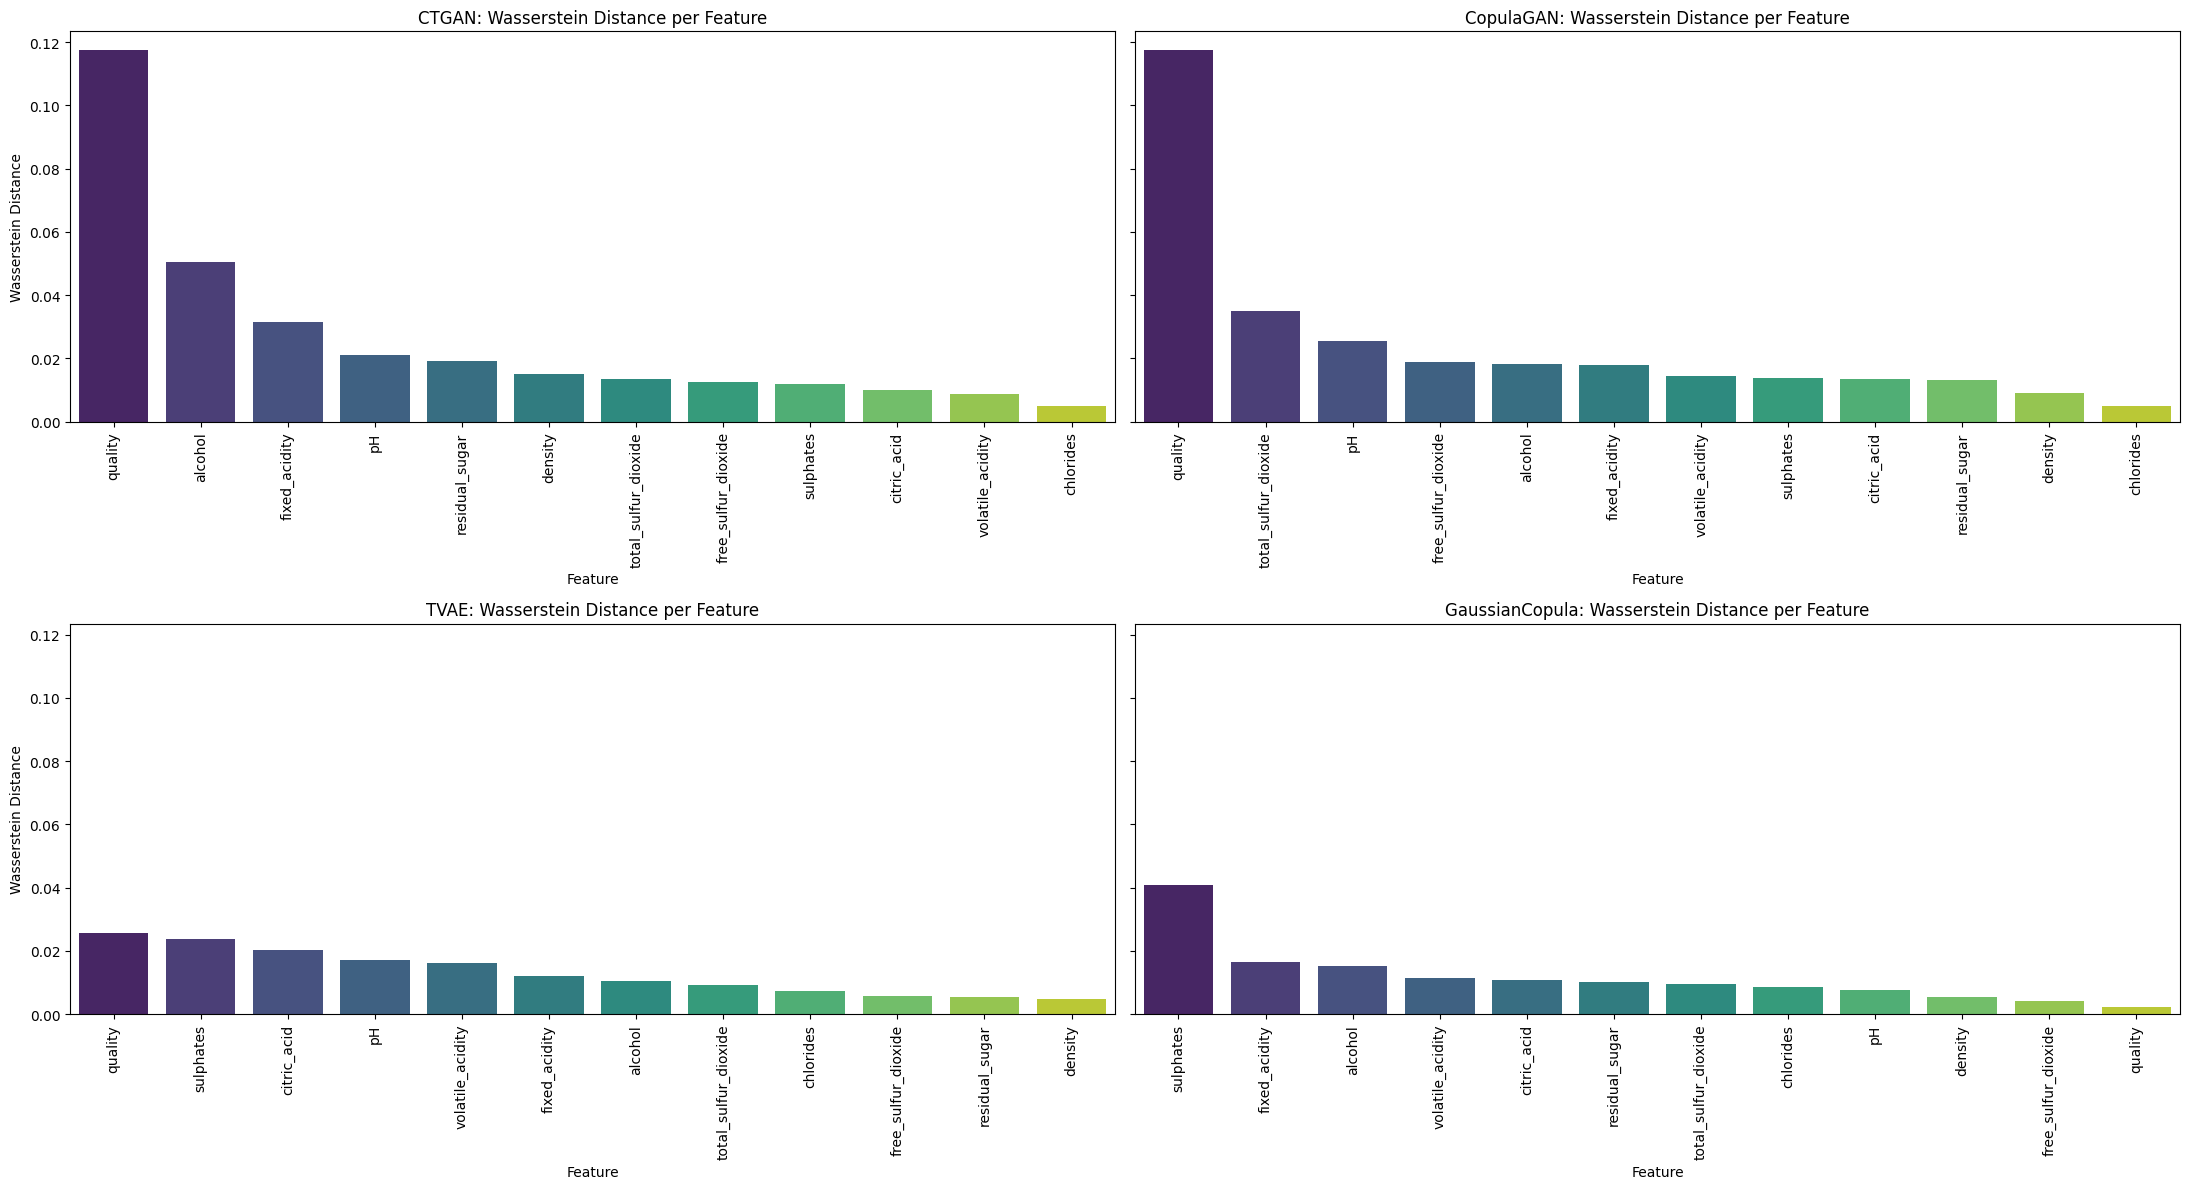

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same column order as real data
    synth_df = synth_df[data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in data.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [8]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "quality"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)



CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8917

Intra-set Similarity (Synthetic):
Max = 0.9839, Avg = 0.8126

Cross-set Similarity (Real vs Synthetic):
Max = 0.9888, Avg = 0.8810

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8917

Intra-set Similarity (Synthetic):
Max = 0.9870, Avg = 0.8155

Cross-set Similarity (Real vs Synthetic):
Max = 0.9902, Avg = 0.8838

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8917

Intra-set Similarity (Synthetic):
Max = 0.9877, Avg = 0.8332

Cross-set Similarity (Real vs Synthetic):
Max = 0.9940, Avg = 0.8984

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8917

Intra-set Similarity (Synthetic):
Max = 0.9845, Avg = 0.8433

Cross-set Similarity (Real vs Synthetic):
Max = 0.9902, Avg = 0.8893


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,1.0,0.891717,0.983899,0.812609,0.988829,0.881018
1,CopulaGAN,1.0,0.891717,0.987006,0.815525,0.990161,0.883799
2,TVAE,1.0,0.891717,0.987740,0.833224,0.993998,0.898376
3,GaussianCopula,1.0,0.891717,0.984487,0.843325,0.990213,0.889308


### 1.5 t-SNE Visualization


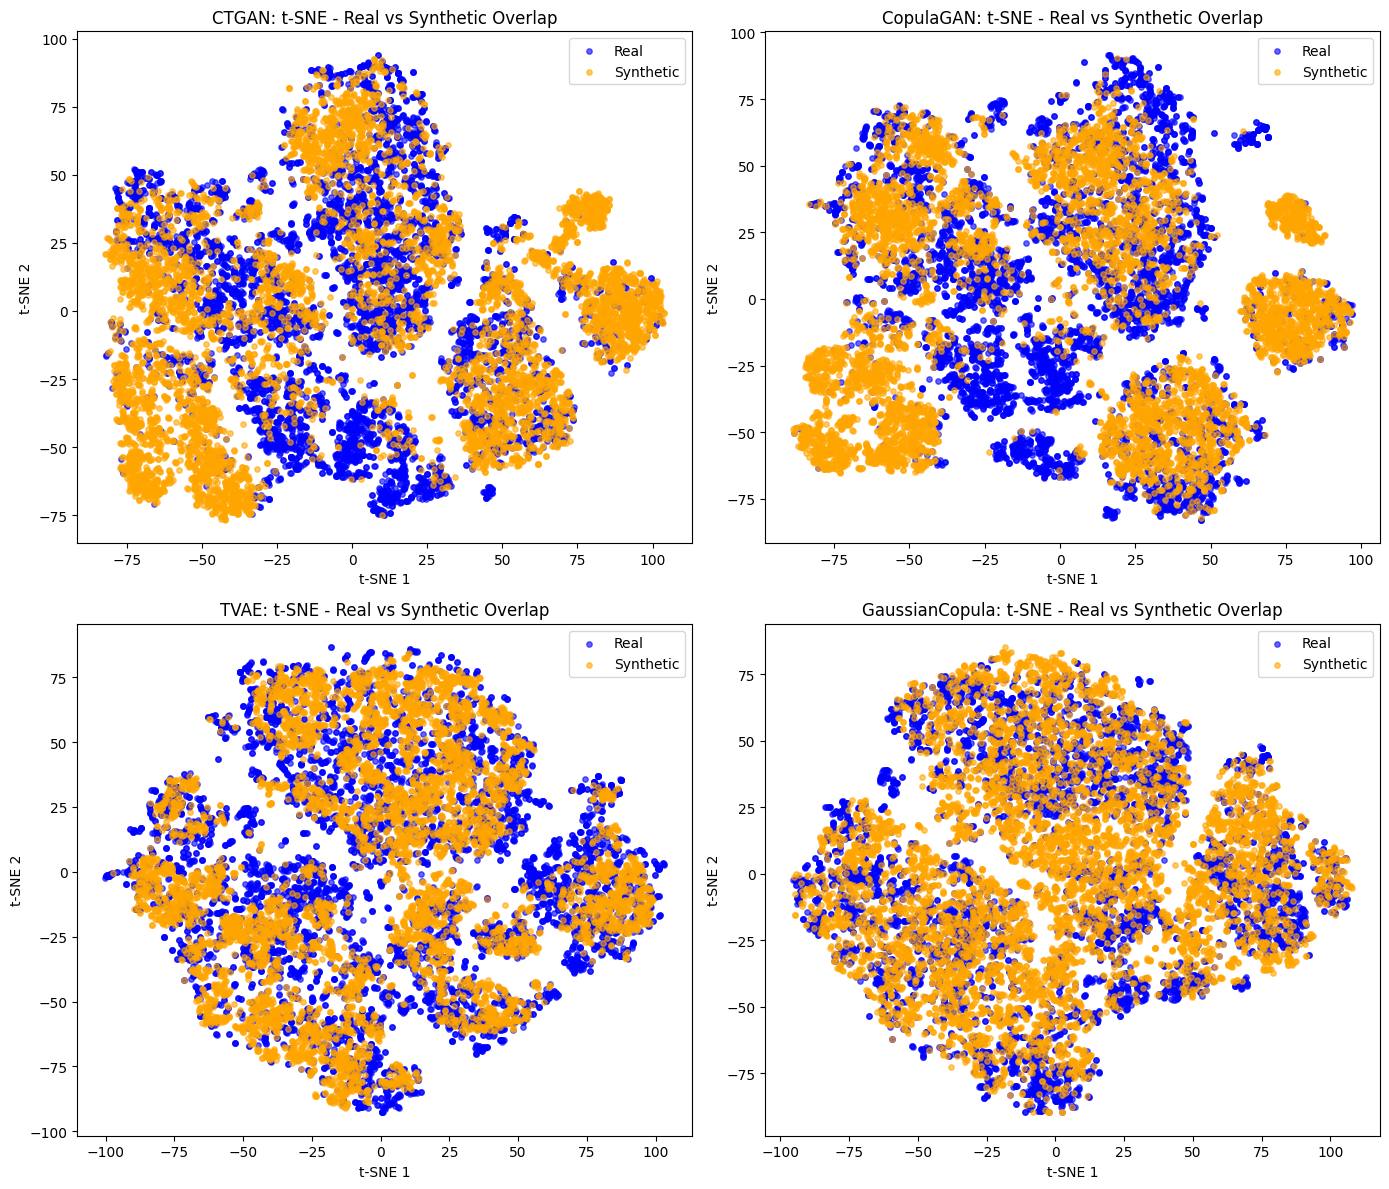

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

# Create 2x2 t-SNE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "quality"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.013173
CopulaGAN - MMD score: 0.009521
TVAE - MMD score: 0.007385
GaussianCopula - MMD score: 0.003268

MMD comparison (lower is better):


,Model,MMD_Score
0,GaussianCopula,0.003268
1,TVAE,0.007385
2,CopulaGAN,0.009521
3,CTGAN,0.013173


### 1.7 Cosine Similarity


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "quality"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].copy()
    X_synth = synth_features[common_cols].copy()

    if "color" in X_real.columns:
        X_real["color"] = X_real["color"].astype("category").cat.codes
        X_synth["color"] = X_synth["color"].astype("category").cat.codes

    X_real = X_real.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    X_synth = X_synth.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0059
Maximum cosine similarity: 0.9945

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0053
Maximum cosine similarity: 0.9960

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0141
Maximum cosine similarity: 0.9960

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0035
Maximum cosine similarity: 0.9905

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.014057,0.996014
1,CTGAN,0.005918,0.994499
2,CopulaGAN,0.005261,0.996017
3,GaussianCopula,0.003519,0.990548


### 1.8 Nearest Neighbours 


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "quality"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.5625
Minimum NN Distance (Synthetic -> Real): 0.4357
5th Percentile NN Distance: 0.8985

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.3998
Minimum NN Distance (Synthetic -> Real): 0.4278
5th Percentile NN Distance: 0.8004

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.9986
Minimum NN Distance (Synthetic -> Real): 0.3112
5th Percentile NN Distance: 0.6431

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.4826
Minimum NN Distance (Synthetic -> Real): 0.4817
5th Percentile NN Distance: 0.8770

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,CTGAN,1.562531,0.435691,0.898490
1,GaussianCopula,1.482607,0.481679,0.876976
2,CopulaGAN,1.399824,0.427752,0.800426
3,TVAE,0.998589,0.311218,0.643059


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,5.266867,3.743189,10.903988
1,CopulaGAN,5.089144,2.686541,12.528307
2,TVAE,3.932436,4.384033,15.013342
3,GaussianCopula,0.506707,0.395139,9.490235


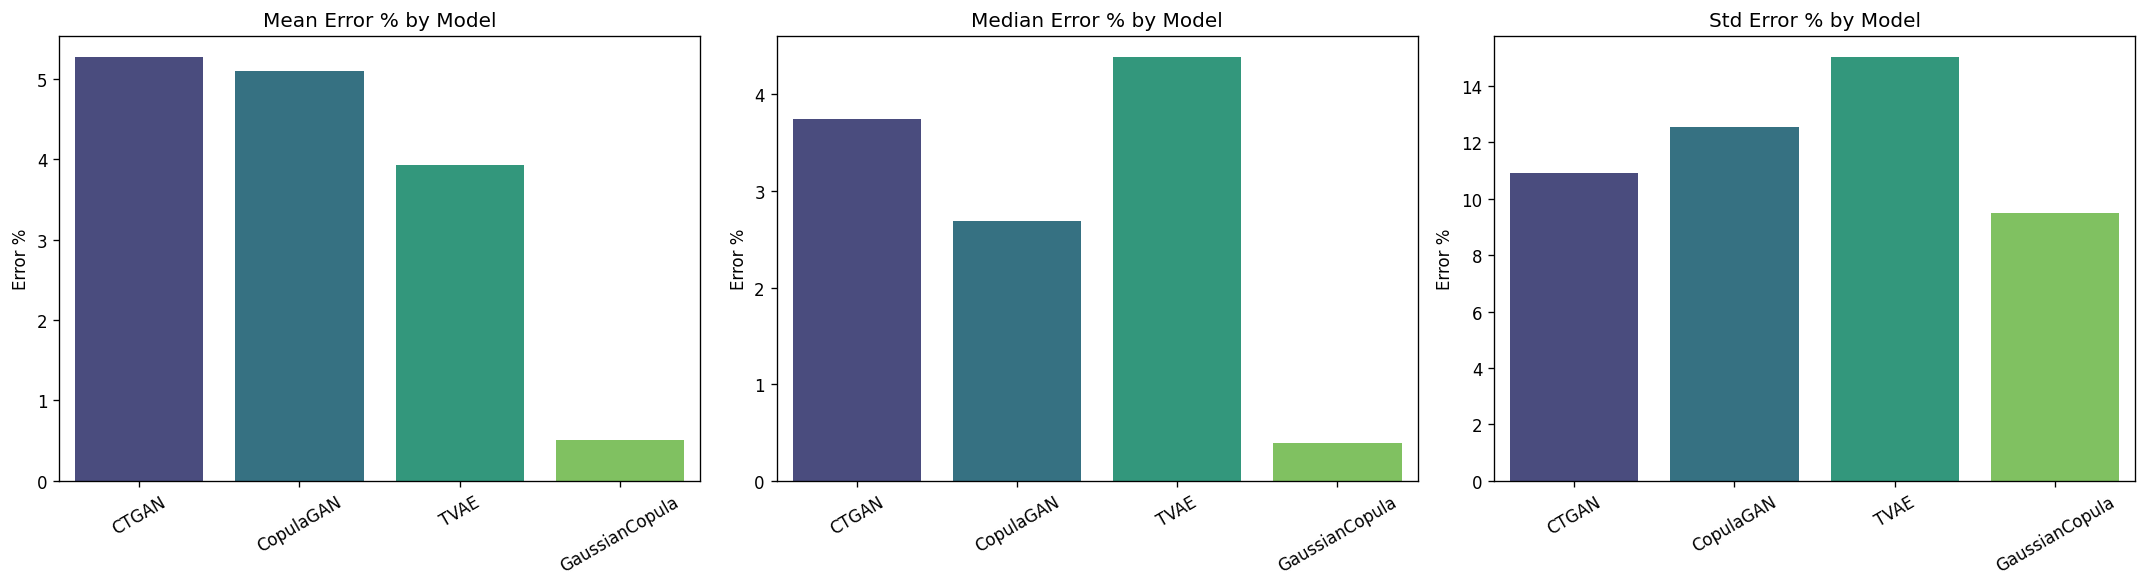

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

drop_from_metrics = []
if "ID" in num_cols:
    drop_from_metrics.append("ID")
if "quality" in num_cols:
    drop_from_metrics.append("quality")

num_cols = [c for c in num_cols if c not in drop_from_metrics]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


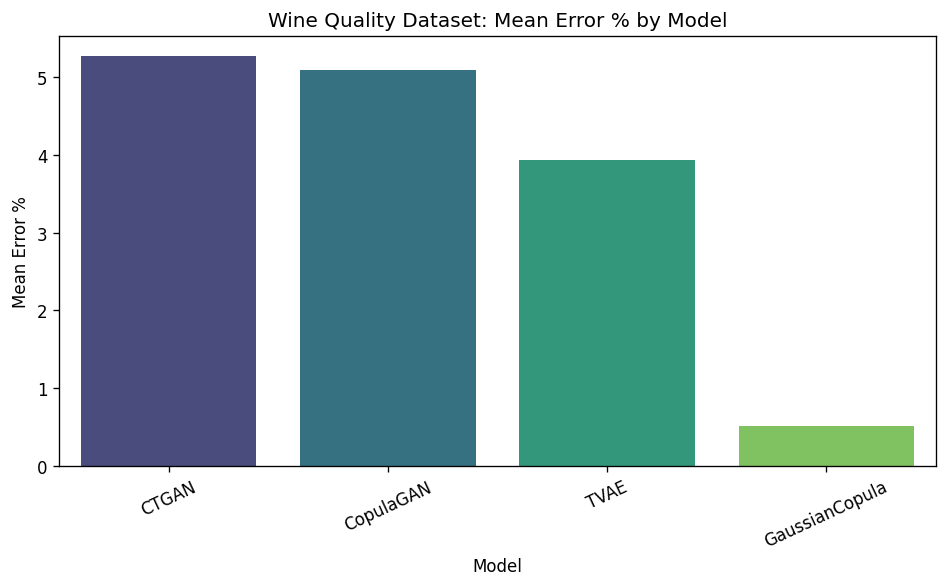

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Wine Quality Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

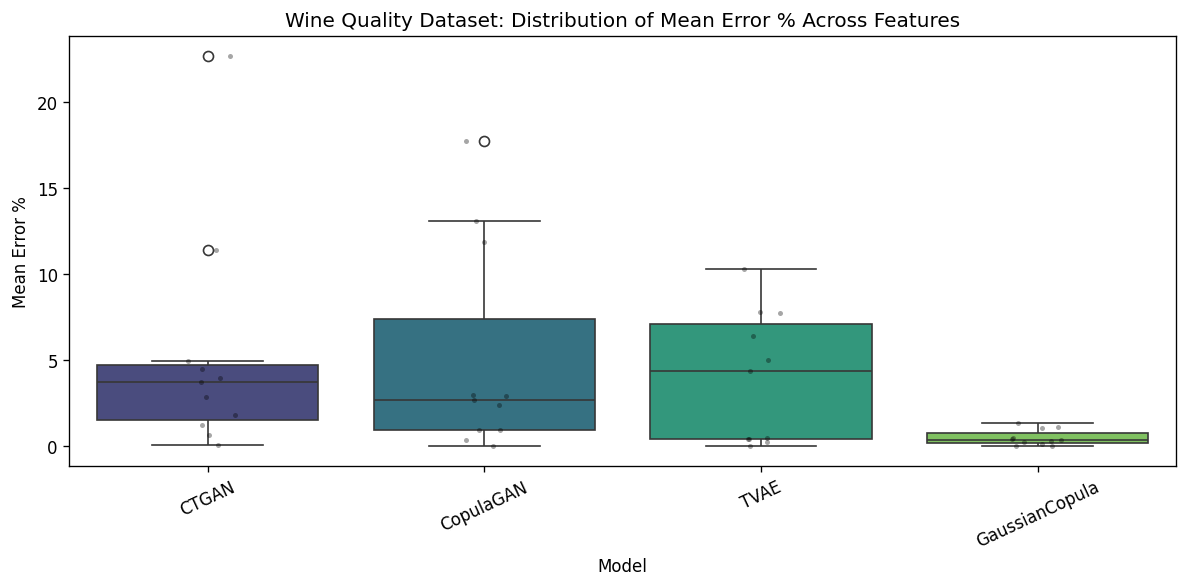

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Wine Quality Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

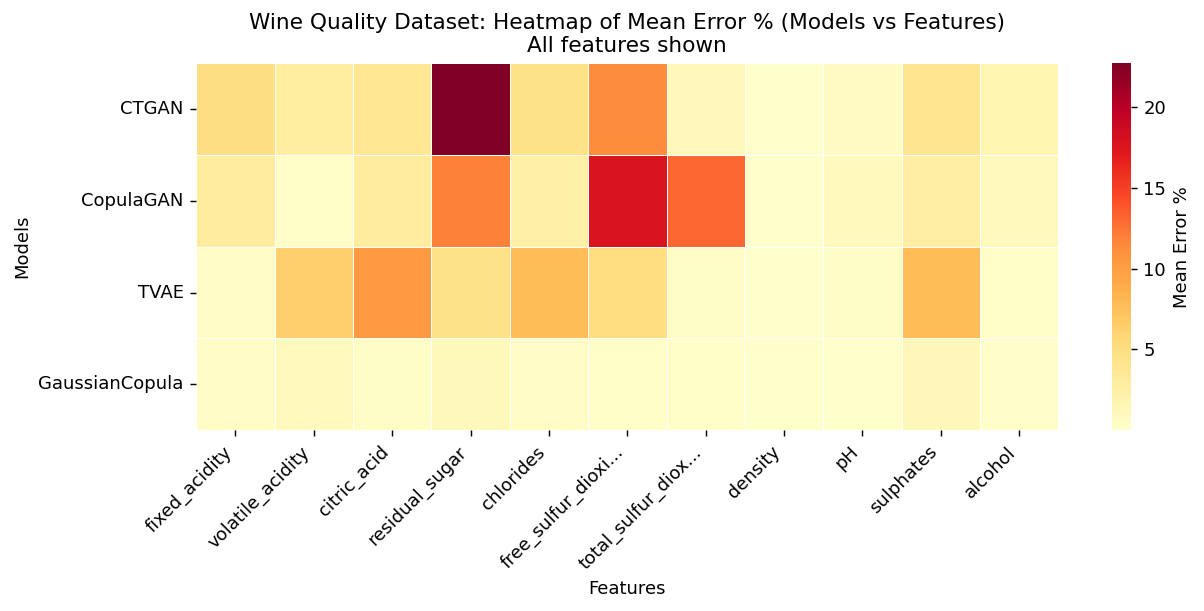

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Wine Quality Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [17]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_regression(real_df, synth_df, target="quality", id_col=None):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in [target, id_col] if c is not None]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    if target in real_scaled.columns and target in synth_scaled.columns:
        for col in num_cols:
            r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
            s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

            if len(r_groups) == 2 and len(s_groups) == 2:
                d_real = stats.wasserstein_distance(*r_groups)
                d_synth = stats.wasserstein_distance(*s_groups)
                results_target.append({
                    "feature": col,
                    "delta_wasserstein": abs(d_real - d_synth)
                })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False) if results_target else pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df


In [18]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

target_col = "quality"
id_col = None

if "bivariate_quality_regression" in globals():
    quality_fn = bivariate_quality_regression
else:
    raise NameError("Define `bivariate_quality_regression` before running this cell.")

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_eval = real_df.drop(columns=[id_col], errors="ignore")
    synth_eval = synth_df.drop(columns=[id_col], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by {target_col} class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and not corr_results.empty else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and not target_results.empty else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
1,fixed_acidity,citric_acid,0.508821
7,fixed_acidity,pH,0.359529
30,residual_sugar,density,0.344200
40,free_sulfur_dioxide,total_sulfur_dioxide,0.316528
33,residual_sugar,alcohol,0.277180
24,citric_acid,pH,0.255208
44,free_sulfur_dioxide,alcohol,0.235795
6,fixed_acidity,density,0.224294
50,density,sulphates,0.208771
29,residual_sugar,total_sulfur_dioxide,0.199454


CTGAN - Features that differ most by quality class:


,feature,delta_wasserstein



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
36,chlorides,density,0.138394
8,fixed_acidity,sulphates,0.138316
38,chlorides,sulphates,0.136127
47,total_sulfur_dioxide,sulphates,0.121032
32,residual_sugar,sulphates,0.093267
11,volatile_acidity,residual_sugar,0.090371
39,chlorides,alcohol,0.082443
41,free_sulfur_dioxide,density,0.072892
30,residual_sugar,density,0.068267
20,citric_acid,chlorides,0.066347


GaussianCopula - Features that differ most by quality class:


,feature,delta_wasserstein


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.508821,0.292978,None,None
1,CopulaGAN,0.556285,0.315203,None,None
2,TVAE,0.224182,0.177655,None,None
3,GaussianCopula,0.138394,0.100746,None,None


### 3 Multivariate Analysis


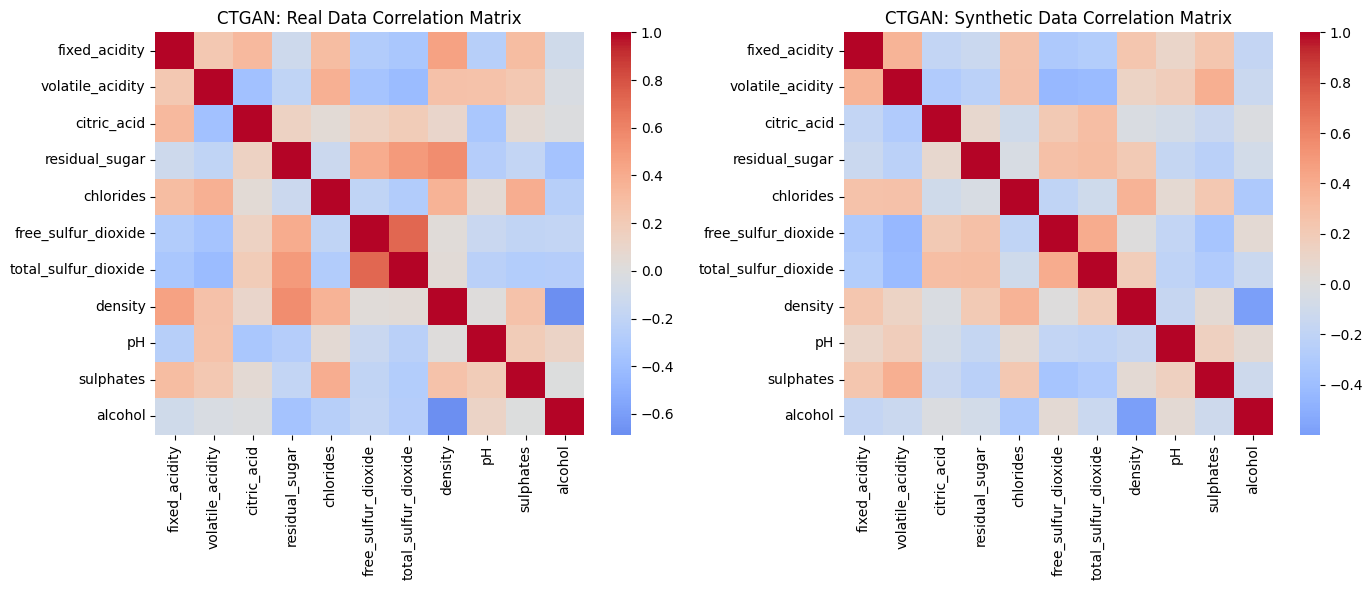

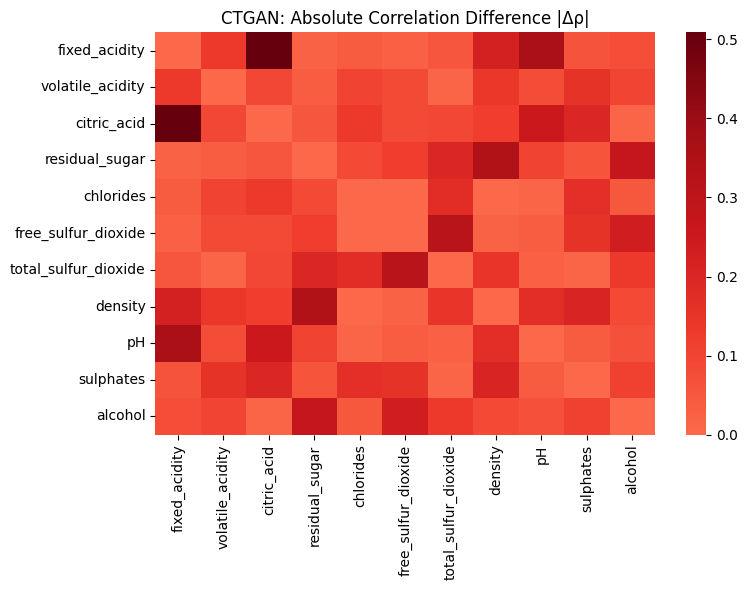

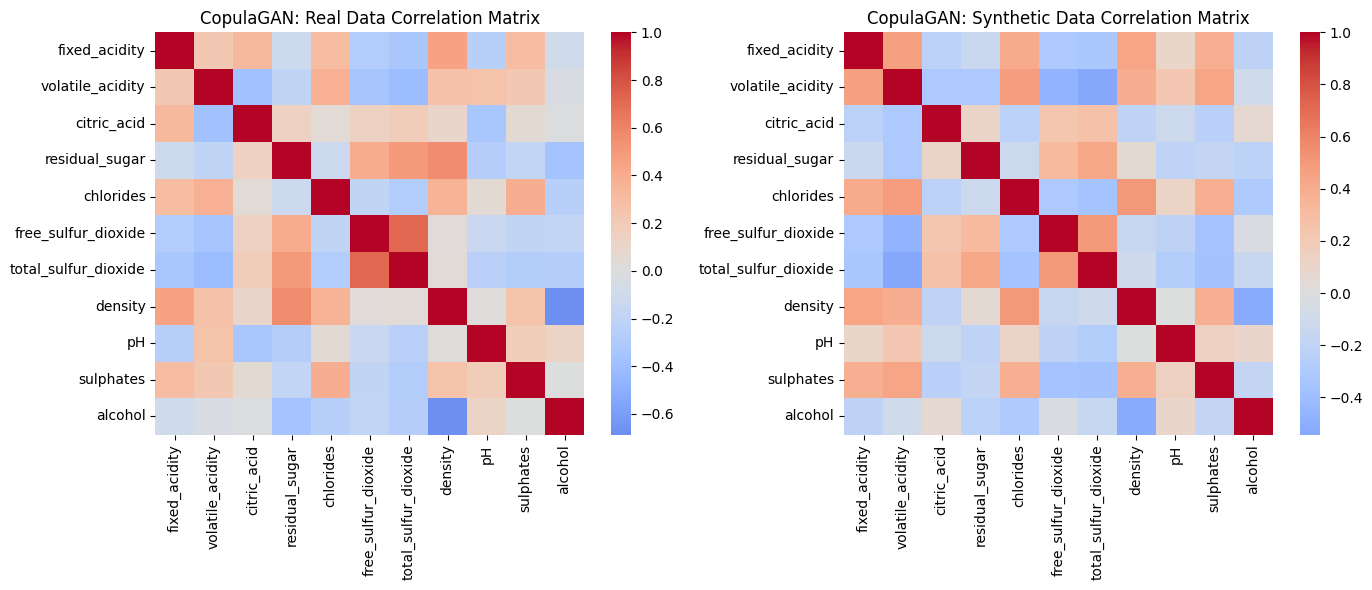

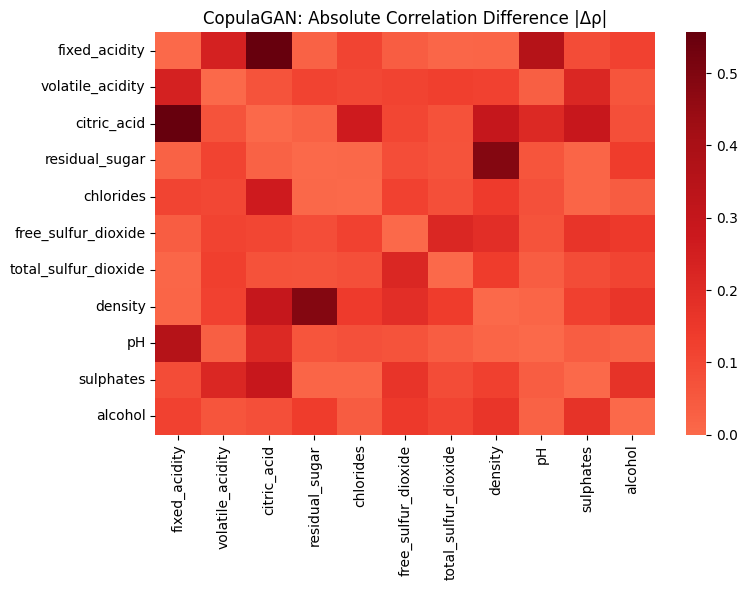

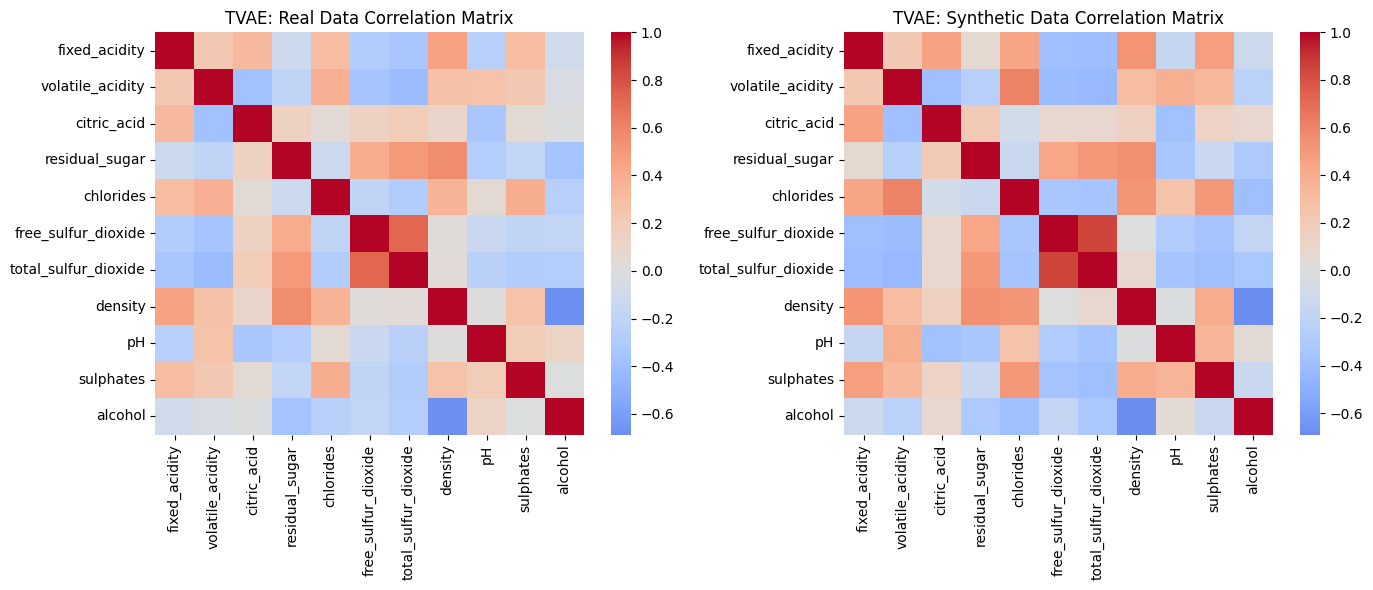

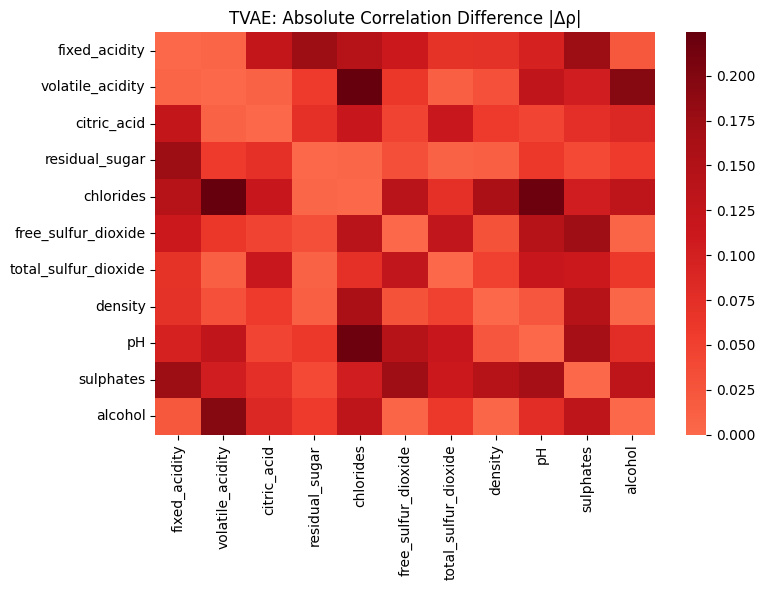

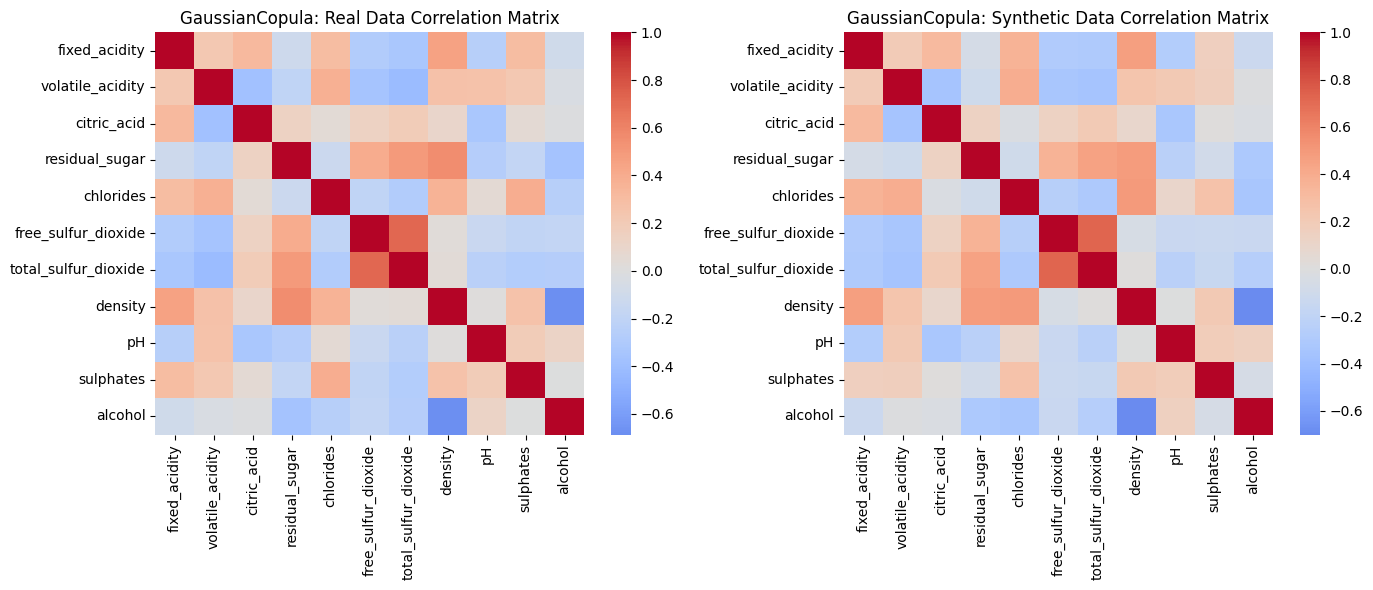

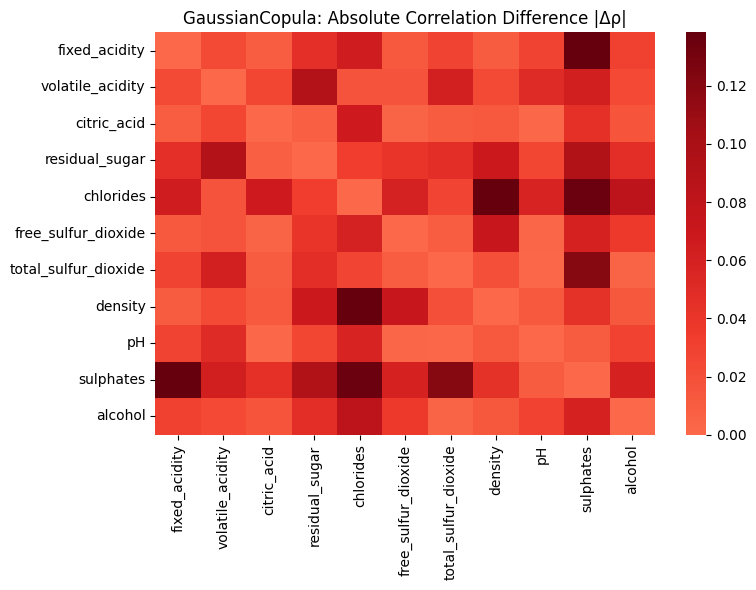

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "quality"
id_col = None

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target_col, id_col] if c is not None]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.011186


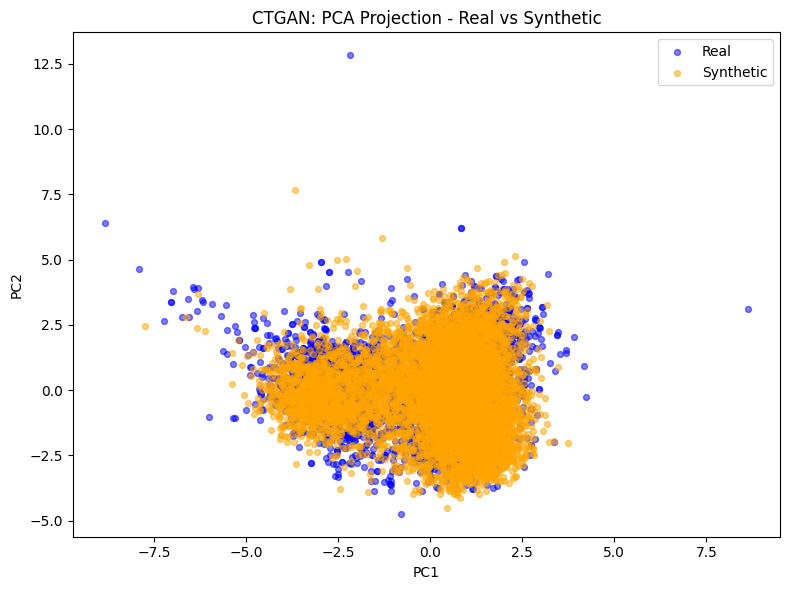

CTGAN - Two-Sample Classifier Accuracy: 0.9205

CopulaGAN - Global MMD (RBF): 0.009166


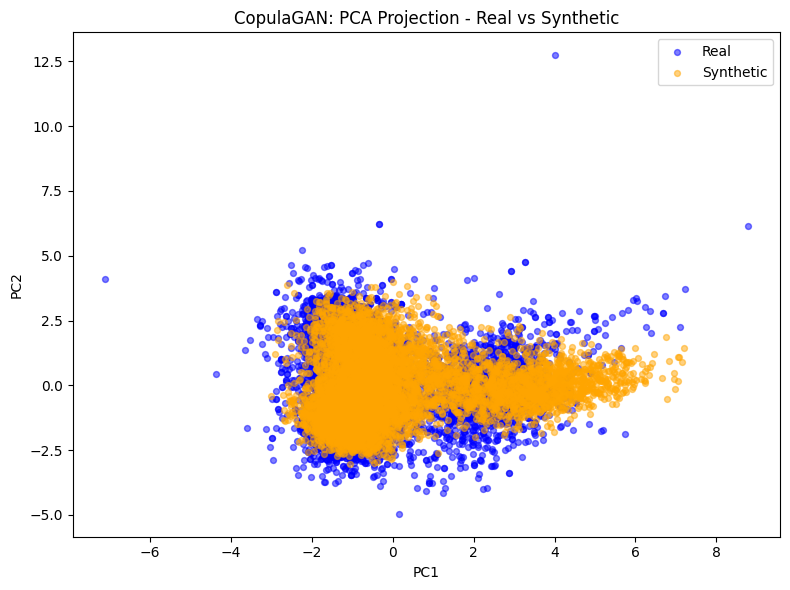

CopulaGAN - Two-Sample Classifier Accuracy: 0.9092

TVAE - Global MMD (RBF): 0.008219


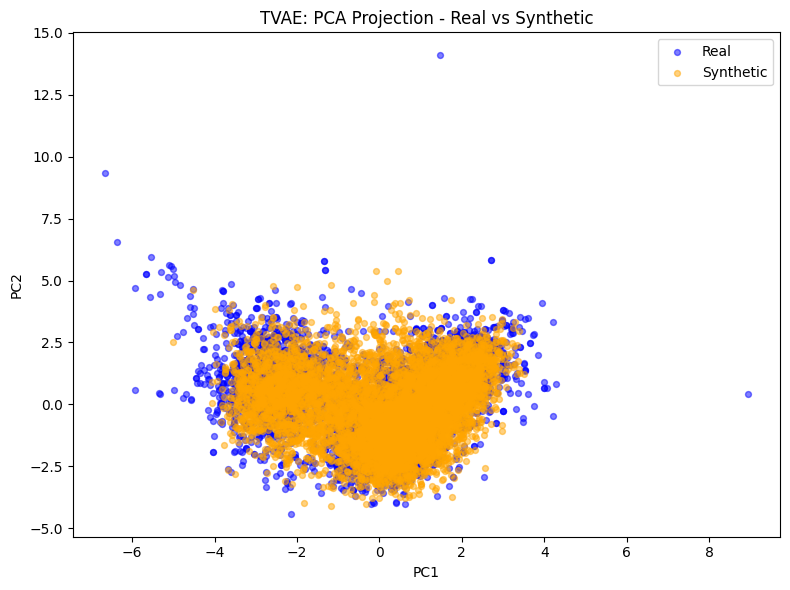

TVAE - Two-Sample Classifier Accuracy: 0.8679

GaussianCopula - Global MMD (RBF): 0.002883


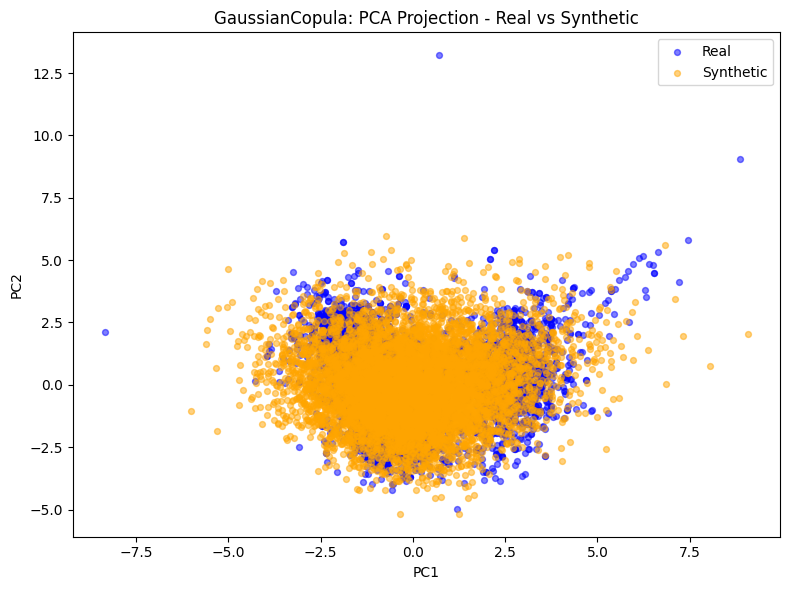

GaussianCopula - Two-Sample Classifier Accuracy: 0.8861

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,GaussianCopula,0.002883,0.886125
1,TVAE,0.008219,0.867915
2,CopulaGAN,0.009166,0.909207
3,CTGAN,0.011186,0.920492


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())


model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "quality"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestRegressor(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regressors 


In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models(train_df, test_df, label, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label]).copy()
    y_train = train_df[label].copy()
    X_test = test_df.drop(columns=[label]).copy()
    y_test = test_df[label].copy()
    X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=test_size, random_state=seed)
    _, X_test, _, y_test = train_test_split(X_test, y_test, test_size=test_size, random_state=seed)
    num_cols = X_train.select_dtypes(include=[np.number]).columns
    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results.append({"Model": name, "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)), "R2": r2_score(y_test, preds)})
    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


In [ ]:
import pandas as pd

label_col = "quality"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []
for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()
    tstr_results = evaluate_models(train_df=synth_train, test_df=data, label=label_col, models=models)
    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)
    comparison = trtr_results.merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("RMSE_Diff", ascending=False)
    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)
    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)
summary = combined_comparison.groupby("Synthetic_Model", as_index=False)["RMSE_Diff"].mean().sort_values("RMSE_Diff")
print("Average RMSE increase by synthetic generator (lower is better):")
display(summary)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return
    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]], on="Model", suffixes=("_TRTR", "_TSTR")
    )
    df["Diff"] = (
        df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
        if metric in ["MAE", "RMSE"]
        else df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    )
    df = df.sort_values("Diff", ascending=False)
    x = np.arange(len(df))
    w = 0.38
    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label="TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label="TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

label_col = "quality"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)
for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()
    tstr_results = evaluate_models(train_df=synth_train, test_df=data, label=label_col, models=models)
    print(f"{synth_name} - TSTR")
    display(tstr_results)
    comparison = trtr_results.merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["Synthetic_Model"] = synth_name
    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)
    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _metric_delta(metric, trtr_val, tstr_val):
    if metric in ("RMSE", "MAE"):
        return tstr_val - trtr_val
    if metric == "R2":
        return trtr_val - tstr_val
    return trtr_val - tstr_val

def plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name, ncols=5):
    metrics = [m for m in ["RMSE", "MAE", "R2"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        metrics = [m for m in ["Accuracy", "F1", "AUC"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        print(f"No common metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))
    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, max(9, 3 * nrows)), dpi=150, constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, model_name in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[model_name].values.astype(float)
        b = tstr.loc[model_name].values.astype(float)
        deltas = [_metric_delta(m, ai, bi) for m, ai, bi in zip(metrics, a, b)]

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="s", label="TSTR")
        ax.fill_between(x, np.minimum(a, b), np.maximum(a, b), alpha=0.2)

        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        for xi, ai, bi, di in zip(x, a, b, deltas):
            ax.text(xi, (ai + bi) / 2, f"{di:+.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(model_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{generator_name} - TRTR vs TSTR per regressor", fontsize=14)
    plt.show()

label_col = "quality"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
for gen in generators:
    _common = [c for c in data.columns if c in synthetic_datasets[gen].columns]
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen][_common],
        test_df=data,
        label=label_col,
        models=models,
    )
    plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name=gen, ncols=5)


# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,5.266867,3.743189,10.903988
1,CopulaGAN,5.089144,2.686541,12.528307
2,TVAE,3.932436,4.384033,15.013342
3,GaussianCopula,0.506707,0.395139,9.490235


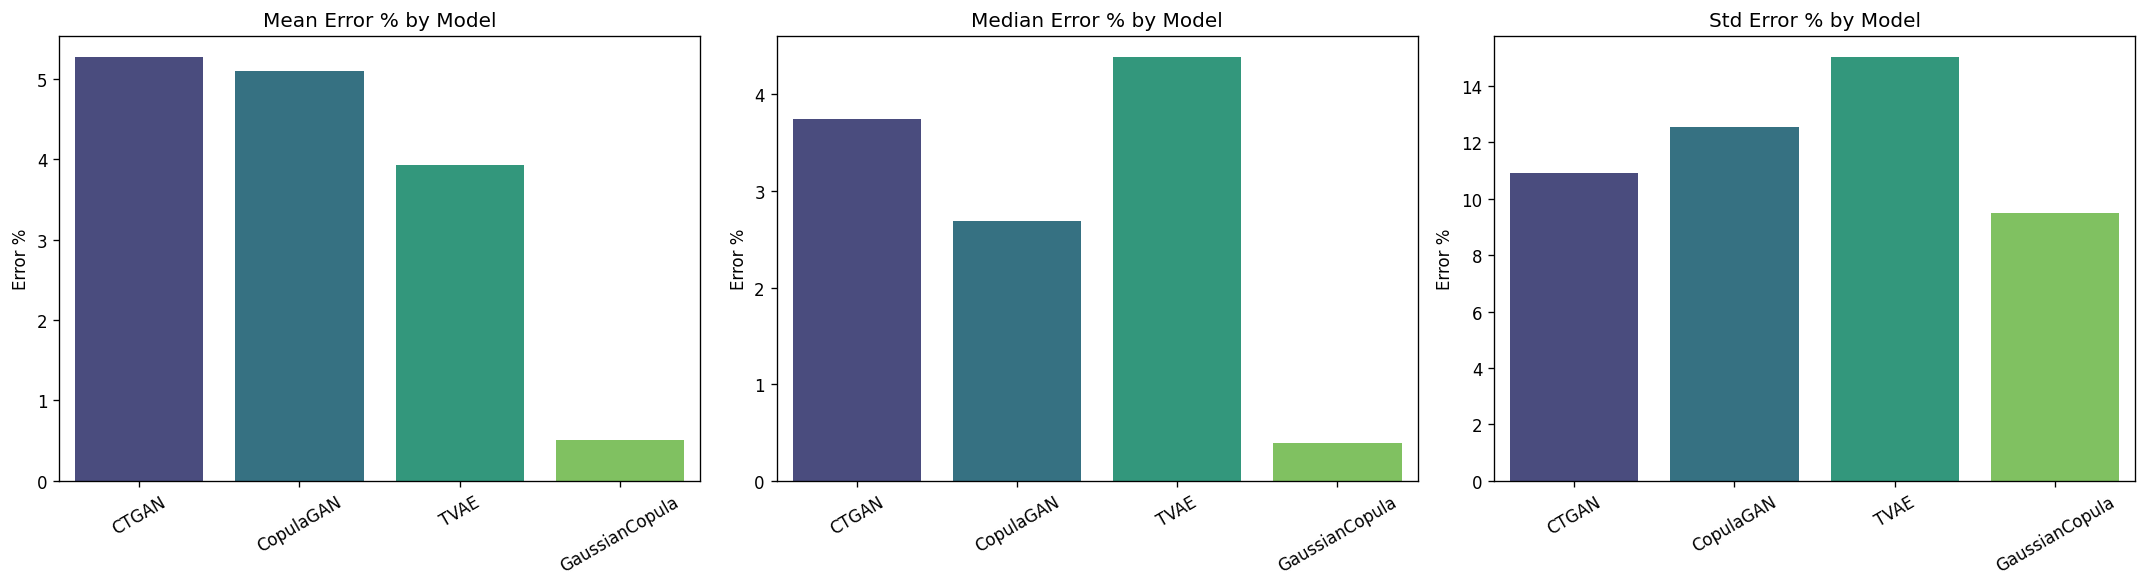

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["quality"]]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


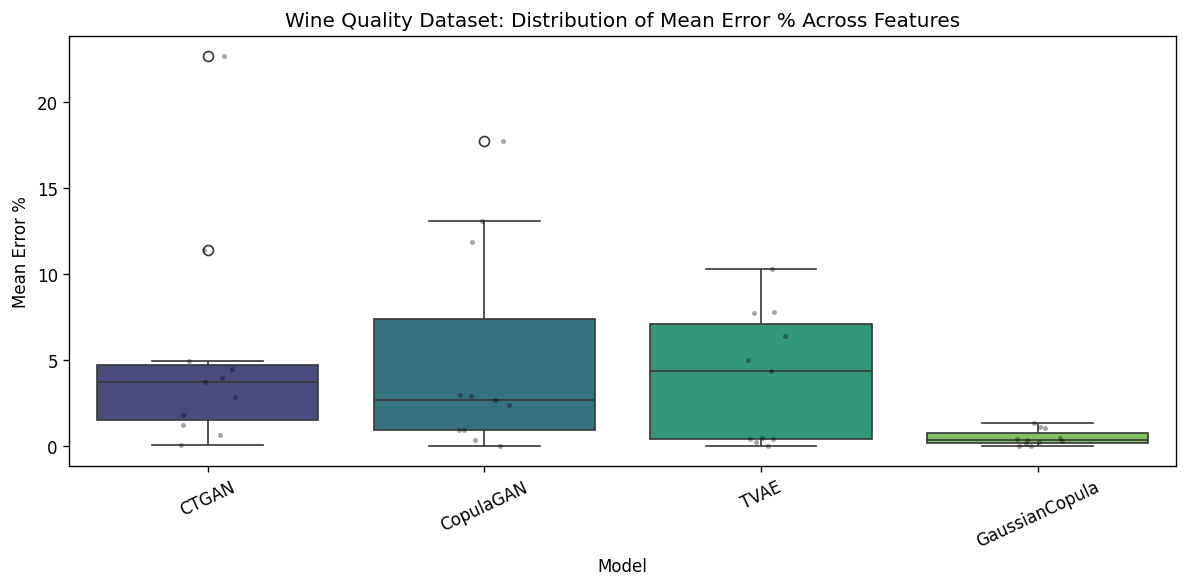

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Wine Quality Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

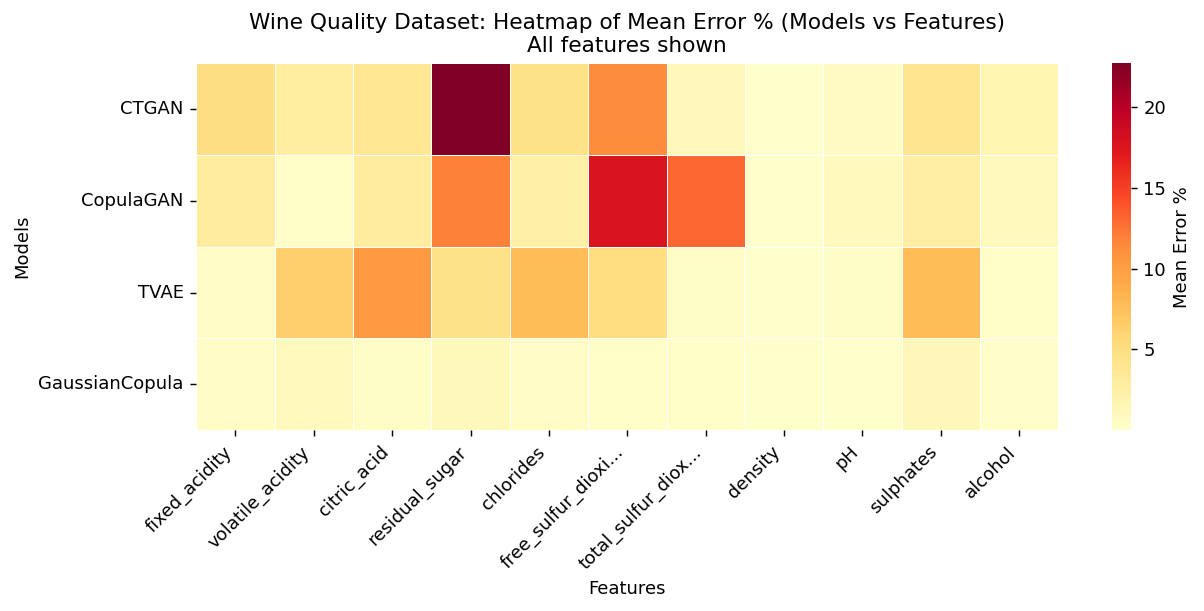

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Wine Quality Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

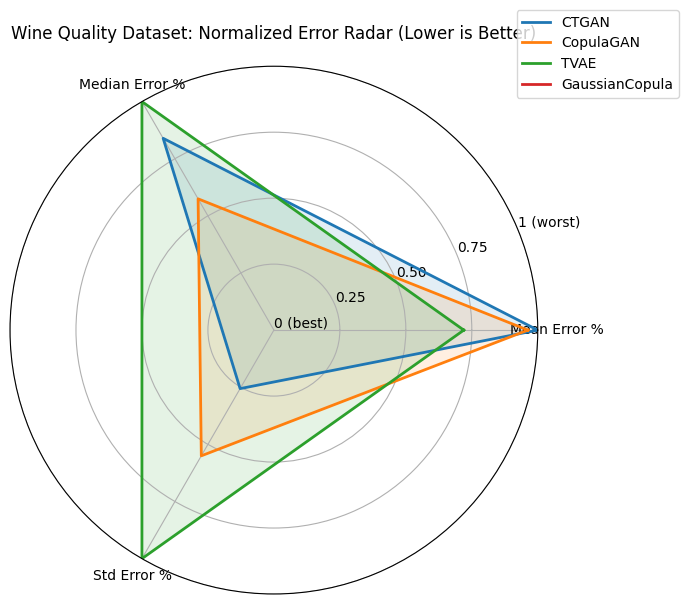

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,1.000000,0.839343,0.255971
1,CopulaGAN,0.962664,0.574446,0.550066
2,TVAE,0.719667,1.000000,1.000000
3,GaussianCopula,0.000000,0.000000,0.000000


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Wine Quality Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CopulaGAN,98.181818,46.0,457.0
1,TVAE,103.181818,59.0,529.0
2,CTGAN,113.000000,47.0,626.0
3,GaussianCopula,143.181818,128.0,458.0


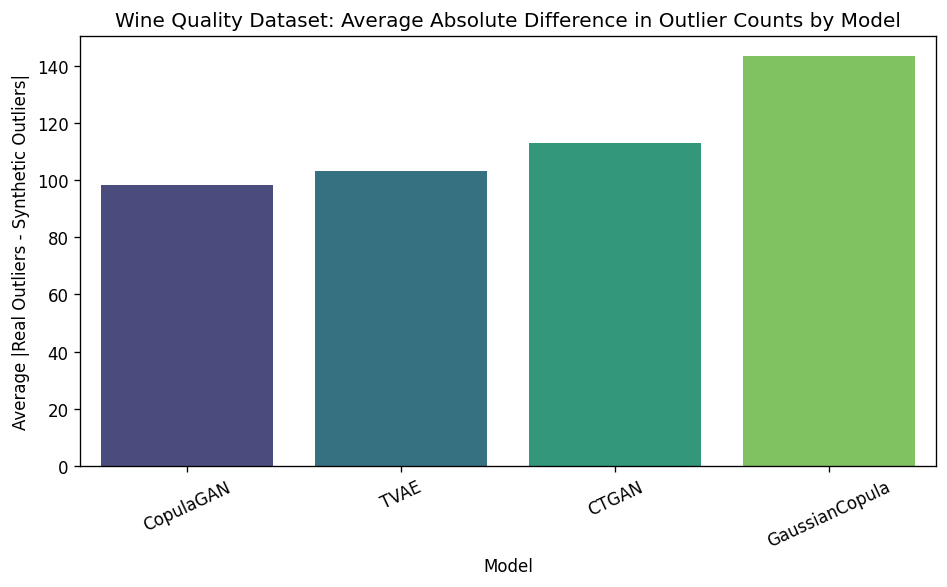

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["quality"]]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Wine Quality Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [36]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "quality"]

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=np.float64))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.973260  0.971479  0.941828  0.966880  0.991132  0.968146  0.968667   
R2   0.978643  0.996819  0.960521  0.994147  0.978774  0.985652  0.993681   
R3   0.990939  0.985270  0.972378  0.979221  0.993936  0.990471  0.989804   
R4   0.988837  0.983761  0.970128  0.978279  0.993003  0.987881  0.987736   
R5   0.973260  0.971479  0.941828  0.966880  0.991132  0.968146  0.968667   
R6   0.979776  0.981101  0.952993  0.976651  0.991688  0.977595  0.979508   
R7   0.994320  0.984464  0.979283  0.977754  0.993561  0.993741  0.992032   
R8   0.860811  0.919010  0.803549  0.925105  0.904306  0.861366  0.883612   
R9   0.880370  0.896858  0.821359  0.897036  0.930972  0.868249  0.874174   
R10  0.998498  0.971972  0.994720  0.961707  0.986239  0.999055  0.990138   

           S8        S9       S10  
R1   0.991755  0.949103  0.976982  
R2   0.999181  0.971976  0.991

,avg_cosine,max_cosine
CTGAN,0.920810,0.999998
CopulaGAN,0.939245,0.999999
TVAE,0.962950,0.999999
GaussianCopula,0.954450,0.999999


In [37]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != "quality"]

    R = real_data[num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns].copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


CTGAN - Top 10 Real -> Synthetic Matchings
01. R2774 -> S5515   cosine similarity = 1.0000
02. R2443 -> S5215   cosine similarity = 1.0000
03. R2450 -> S5215   cosine similarity = 1.0000
04. R3612 -> S6408   cosine similarity = 1.0000
05. R2841 -> S5163   cosine similarity = 1.0000
06. R3364 -> S2747   cosine similarity = 1.0000
07. R3356 -> S2747   cosine similarity = 1.0000
08. R1931 -> S2690   cosine similarity = 1.0000
09. R3677 -> S6344   cosine similarity = 1.0000
10. R4604 -> S3969   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R5369 -> S5408   cosine similarity = 1.0000
02. R5367 -> S5408   cosine similarity = 1.0000
03. R5366 -> S5408   cosine similarity = 1.0000
04. R5365 -> S5408   cosine similarity = 1.0000
05. R1757 -> S3403   cosine similarity = 1.0000
06. R1760 -> S3403   cosine similarity = 1.0000
07. R2774 -> S2102   cosine similarity = 1.0000
08. R5858 -> S3403   cosine similarity = 1.0000
09. R3494 -> S2151   cosine similarity = 1.0

In [38]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "quality"]

    R = real_df[num_cols].to_numpy(dtype=np.float64)
    S = synth_df[num_cols].to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()
results = {}

for name in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding quality)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")


CTGAN: Hungarian matching (cosine, numeric features excluding quality)
Average cosine similarity (Hungarian match): 0.9852

R3993 <-> S2104   cosine similarity = 1.0000
R1746 <-> S5153   cosine similarity = 1.0000
R5143 <-> S4121   cosine similarity = 1.0000
R3689 <-> S2471   cosine similarity = 1.0000
R1855 <-> S2550   cosine similarity = 1.0000
R5149 <-> S5781   cosine similarity = 1.0000
R2952 <-> S4029   cosine similarity = 1.0000
R3684 <-> S6355   cosine similarity = 1.0000
R5714 <-> S2080   cosine similarity = 1.0000
R3589 <-> S3671   cosine similarity = 1.0000

CopulaGAN: Hungarian matching (cosine, numeric features excluding quality)
Average cosine similarity (Hungarian match): 0.9946

R5367 <-> S5408   cosine similarity = 1.0000
R4030 <-> S6481   cosine similarity = 1.0000
R5008 <-> S2859   cosine similarity = 1.0000
R2116 <-> S1267   cosine similarity = 1.0000
R3248 <-> S1540   cosine similarity = 1.0000
R6482 <-> S5361   cosine similarity = 1.0000
R3568 <-> S2511   cosine s

In [39]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "quality"]

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_WineQuality.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]

        if "similarities" in results[model_name]:
            score_key = "cosine_similarity"
            scores = results[model_name]["similarities"]
        elif "distances" in results[model_name]:
            score_key = "mahalanobis_distance"
            scores = results[model_name]["distances"]
        else:
            raise KeyError(f"No score array found for model {model_name}. Expected 'similarities' or 'distances'.")

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns].copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)


Saved: Hungarian_Matchings_All_Models_Heart.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
2,TVAE,6497,0.998323,0.999600,0.951858,0.999998
3,GaussianCopula,6497,0.997174,0.999837,0.800608,0.999996
1,CopulaGAN,6497,0.994558,0.999498,0.748258,0.999999
0,CTGAN,6497,0.985166,0.998678,0.708803,0.999992


# 7. Mahalanobis distance with Hungrain Mapping  

In [40]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "quality"]

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real feature data.")
print(f"Used features: {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")


Fitted mean and inverse covariance on real feature data.
Used features: 12
Mean shape: (12,), Inv_cov shape: (12, 12)


In [41]:
mahalanobis_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "quality"]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)


Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,2.782076,2.721351,0.733464,0.982752,11.542137
GaussianCopula,3.546674,3.357429,1.065035,1.448766,11.568635
CopulaGAN,4.300939,4.099258,1.333974,1.291840,13.616778
CTGAN,4.686619,4.456700,1.551139,1.424993,17.760690


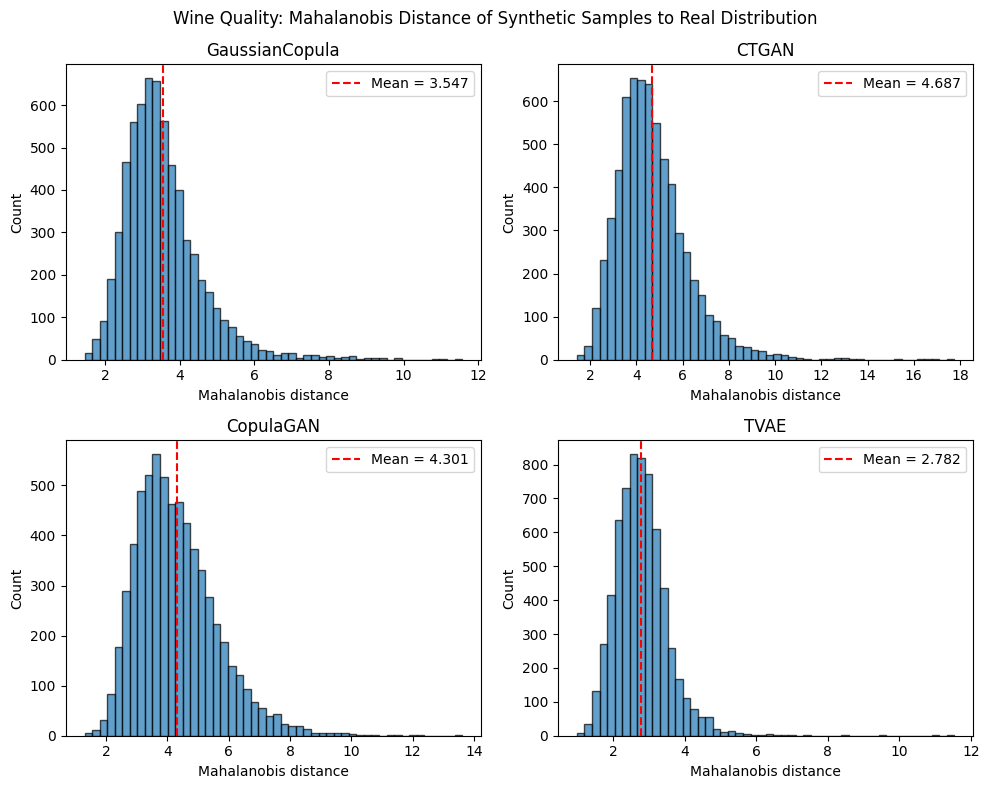

In [43]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Wine Quality: Mahalanobis Distance of Synthetic Samples to Real Distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
fig_dir = os.path.join(ROOT, "figures")
os.makedirs(fig_dir, exist_ok=True)

plt.savefig(
    os.path.join(fig_dir, "mahalanobis_winequality_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [44]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "quality"]

real_matrix = data[num_cols].to_numpy(dtype=np.float64)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
TVAE,13.651015,11.338925,10.051404,126.081667
CTGAN,14.600134,12.454298,10.254830,101.637359
CopulaGAN,14.972495,12.788552,10.427390,112.151425
GaussianCopula,15.507334,13.074288,11.630429,219.902169


In [45]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "quality"]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,1.600001e+11,8.000004e+07
CTGAN,7.000009e+10,3.500005e+07
CopulaGAN,4.500001e+11,2.250000e+08
TVAE,6.000009e+10,3.000004e+07



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,2000,1.600001e+11,100751.151988,8.000004e+07,15.507334,1.600000e+11,8.000002e+07
CTGAN,2000,7.000009e+10,94857.073778,3.500005e+07,14.600134,7.000000e+10,3.500003e+07
CopulaGAN,2000,4.500001e+11,97276.297350,2.250000e+08,14.972495,4.500000e+11,2.250000e+08
TVAE,2000,6.000009e+10,88690.645418,3.000004e+07,13.651015,6.000000e+10,3.000003e+07


In [46]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "quality"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 11
GaussianCopula: avg matched Mahalanobis distance = 2.0111
CTGAN: avg matched Mahalanobis distance = 2.8762
CopulaGAN: avg matched Mahalanobis distance = 2.4998
TVAE: avg matched Mahalanobis distance = 1.8482


In [47]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "quality"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 11
GaussianCopula: avg matched Mahalanobis distance = 2.0111
CTGAN: avg matched Mahalanobis distance = 2.8762
CopulaGAN: avg matched Mahalanobis distance = 2.4998
TVAE: avg matched Mahalanobis distance = 1.8482


In [48]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "quality"]

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S1479   distance = 2.5672
R2 -> S3673   distance = 2.7827
R3 -> S5009   distance = 2.8719
R4 -> S2995   distance = 5.6269
R5 -> S5459   distance = 2.7913
R6 -> S2572   distance = 1.9852
R7 -> S838   distance = 4.5037
R8 -> S156   distance = 2.9184
R9 -> S1313   distance = 2.1395
R10 -> S2262   distance = 5.0420
R11 -> S1213   distance = 1.3584
R12 -> S2059   distance = 2.8211
R13 -> S4401   distance = 2.9779
R14 -> S304   distance = 4.2935
R15 -> S1846   distance = 3.7191
R16 -> S3512   distance = 3.9014
R17 -> S374   distance = 2.4258
R18 -> S4760   distance = 5.2954
R19 -> S291   distance = 2.7542
R20 -> S1713   distance = 4.7405

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S1743   distance = 2.9311
R2 -> S4034   distance = 2.4056
R3 -> S4274   distance = 2.5821
R4 -> S428   distance = 4.0896
R5 -> S1072   distance = 2.0906
R6 -> S2935   distance = 1.7747
R7 -> S3968   distance = 1.7750
R8 -> S1595   distance = 2.4049
R9 -> S90

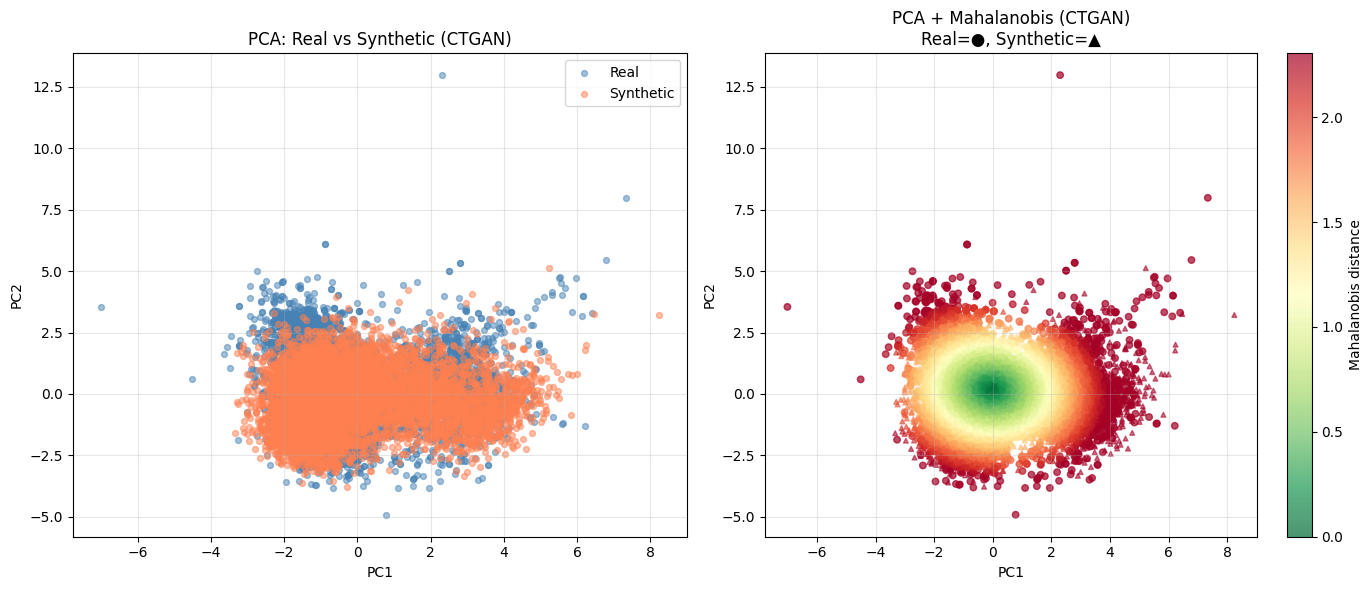

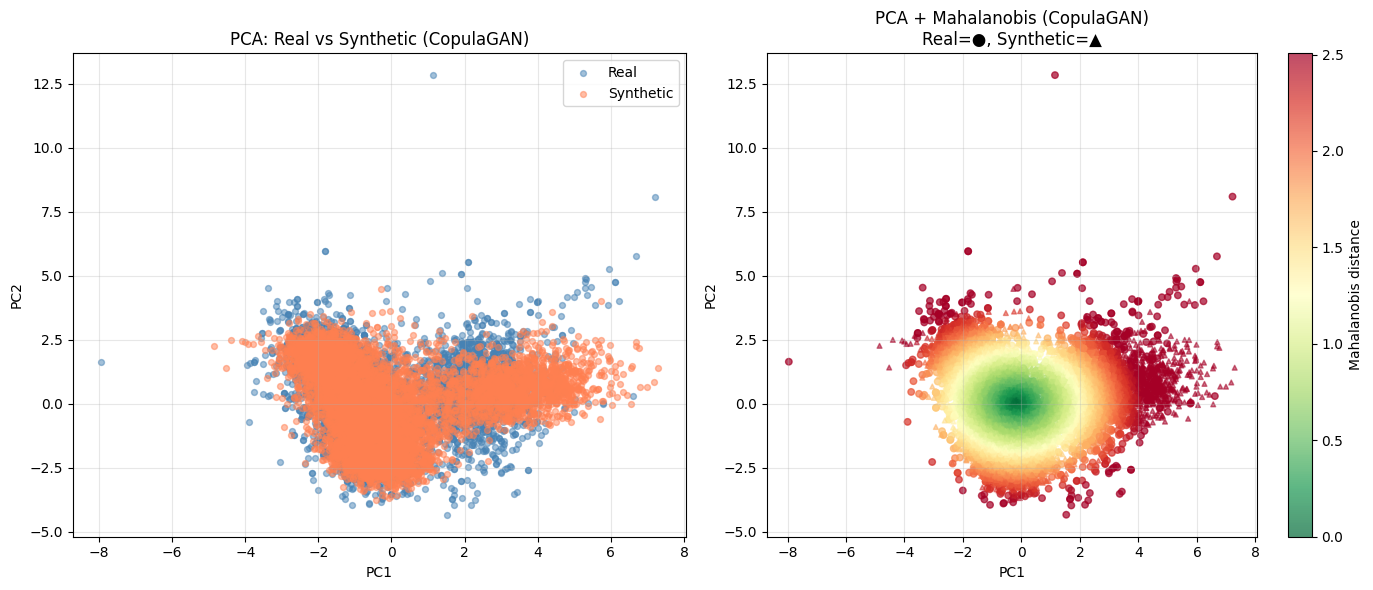

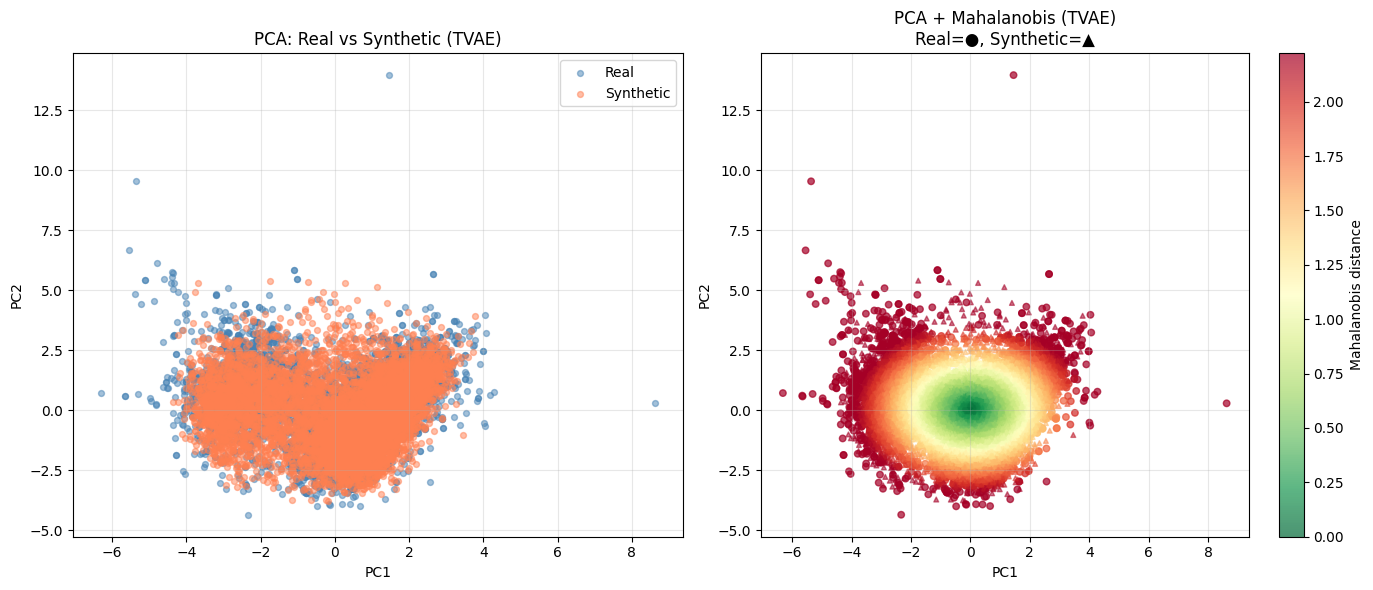

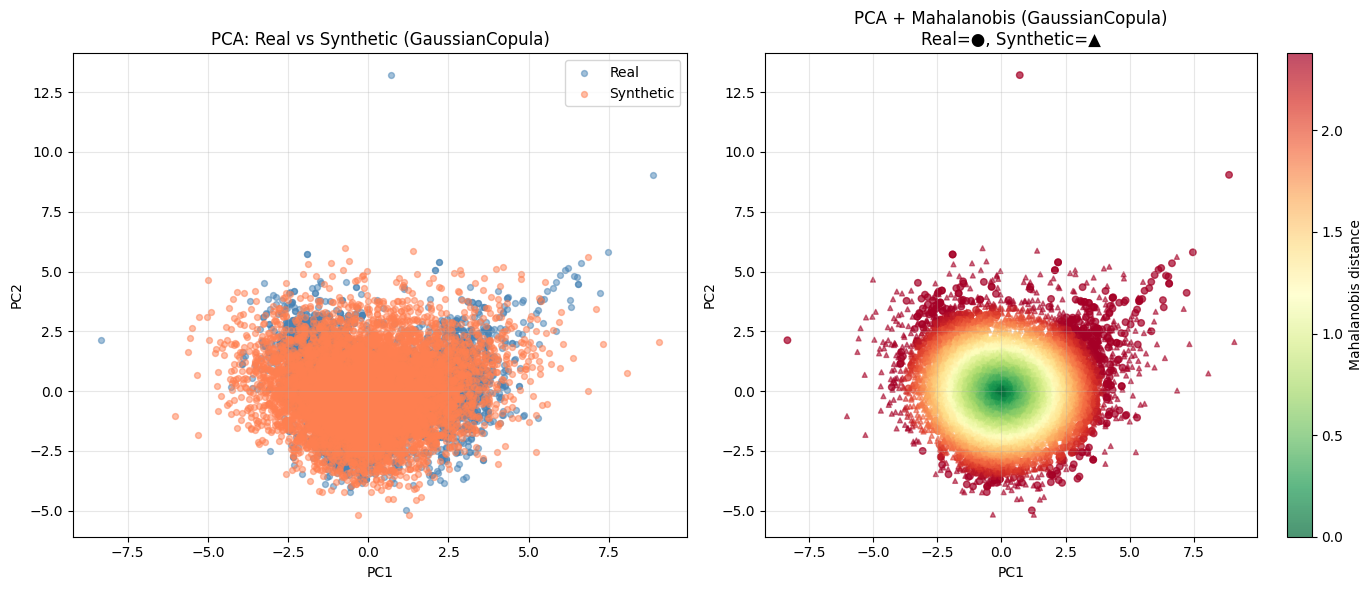

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTGAN,1.263970,1.185716,-0.078253
2,TVAE,1.263153,1.250268,-0.012886
3,GaussianCopula,1.257244,1.252170,-0.005074
1,CopulaGAN,1.266176,1.383828,0.117652


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "quality"]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)

In [50]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_WineQuality.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": "WineQuality",
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"Wine_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)

            summary_rows.append({
                "Dataset": "WineQuality",
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Wine_Summary", index=False)

    print(f"Excel file created: {filename}")


# ---- Run ----
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "quality"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_WineQuality.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_WineQuality.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [51]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    return (y - model.predict(X)) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    model.fit(X_train_s, y_train)
    loss_train = model_loss_per_sample_regression(model, X_train_s, y_train)
    loss_test = model_loss_per_sample_regression(model, X_test_s, y_test)
    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    return {"AUC": float(roc_auc_score(labels, scores)), "Advantage": float(np.max(tpr - fpr))}

target_col = "quality"
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]
real_df = data.copy()
synth_key = next(iter(synthetic_data)) if "synthetic_data" in globals() else next(iter(synthetic_outputs))
synth_src = synthetic_data if "synthetic_data" in globals() else synthetic_outputs
_common = [c for c in real_df.columns if c in synth_src[synth_key].columns]
synth_df = synth_src[synth_key][_common].copy()
model = Ridge(alpha=1.0, random_state=42)
print(privacy_metrics_mia_regression(
    model,
    real_df[feature_cols].to_numpy(dtype=np.float64),
    real_df[target_col].to_numpy(dtype=np.float64),
    synth_df[feature_cols].to_numpy(dtype=np.float64),
    synth_df[target_col].to_numpy(dtype=np.float64),
))


{'AUC': 0.5104469547269055, 'Advantage': np.float64(0.05371710020009235), 'TPR_at_FPR_001': np.float64(0.0029244266584577496)}


In [52]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "quality"]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTGAN,0.843152,0.550100,0.076959,3.096688,5.259564
1,CopulaGAN,0.792671,0.453286,0.075419,3.096688,4.674863
2,GaussianCopula,0.640882,0.213021,0.043559,3.096688,3.537509
3,TVAE,0.491295,0.002924,0.009851,3.096688,3.018209
